In [1]:
"""
=============================================================================
PART 1 — Config, utilities, and multi-dataset loaders
Open-Vocabulary Segmentation with Iterative CLIP-Guided Refinement
 
Benchmarks targeted (matching radar chart):
  COCO Object      - COCO val2017, thing categories
  COCO Stuff       - COCO val2017, stuff categories
  PASCAL VOC       - VOC2012 val, 20 foreground classes
  PASCAL Context   - Pascal Context val, 59 classes
  PASCAL Context59 - same split, 59-class variant
  ADE20k           - ADE20k val, 150 categories
=============================================================================
"""

'\n=============================================================================\nPART 1 — Config, utilities, and multi-dataset loaders\nOpen-Vocabulary Segmentation with Iterative CLIP-Guided Refinement\n \nBenchmarks targeted (matching radar chart):\n  COCO Object      - COCO val2017, thing categories\n  COCO Stuff       - COCO val2017, stuff categories\n  PASCAL VOC       - VOC2012 val, 20 foreground classes\n  PASCAL Context   - Pascal Context val, 59 classes\n  PASCAL Context59 - same split, 59-class variant\n  ADE20k           - ADE20k val, 150 categories\n=============================================================================\n'

In [2]:
# ── Installs ──────────────────────────────────────────────────────────────────
%pip install -q open_clip_torch opencv-python scikit-image transformers accelerate
%pip install -q pycocotools scikit-learn joblib
%pip install -q git+https://github.com/facebookresearch/segment-anything.git
%pip install -q git+https://github.com/facebookresearch/sam2.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install git+https://github.com/lucasb-eyer/pydensecrf.git


  Cloning https://github.com/lucasb-eyer/pydensecrf.git to /tmp/pip-req-build-14zddhy1
  Running command git clone --filter=blob:none --quiet https://github.com/lucasb-eyer/pydensecrf.git /tmp/pip-req-build-14zddhy1
  Resolved https://github.com/lucasb-eyer/pydensecrf.git to commit 2723c7fa4f2ead16ae1ce3d8afe977724bb8f87f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydensecrf: filename=pydensecrf-1.0-cp312-cp312-linux_x86_64.whl size=3494536 sha256=49f195b5e4f75e920366757b678b0b14ae1fb620933a8ed7c51a5727397315be
  Stored in directory: /tmp/pip-ephem-wheel-cache-4nmwti1b/wheels/5f/63/9b/ad8357747651277615ec2094c768471e8ecde7d7b53564f24d
Successfully built pydensecrf
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os, gc, json, math, time, random, hashlib, inspect, re, warnings
from contextlib import nullcontext
from dataclasses import dataclass, asdict, field
from pathlib import Path
from typing import List, Dict, Any, Optional, Tuple, Set
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
from PIL import Image
import joblib
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.ops import nms
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pycocotools.coco import COCO
import open_clip
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection


In [5]:
HAS_SAM1 = False
try:
    from segment_anything import sam_model_registry, SamPredictor
    HAS_SAM1 = True
except Exception as e:
    print('[import] SAM1 unavailable:', repr(e))

HAS_SAM2 = False
try:
    from sam2.build_sam import build_sam2
    from sam2.sam2_image_predictor import SAM2ImagePredictor
    from hydra.core.global_hydra import GlobalHydra
    from hydra import initialize_config_dir
    HAS_SAM2 = True
except Exception as e:
    print('[import] SAM2 unavailable:', repr(e))

HAS_CRF = False
try:
    import pydensecrf.densecrf as dcrf
    from pydensecrf.utils import unary_from_labels, create_pairwise_bilateral, create_pairwise_gaussian
    HAS_CRF = True
except Exception:
    print('[import] pydensecrf unavailable — CRF refinement disabled')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE =', DEVICE)
if DEVICE == 'cuda':
    print('GPU =', torch.cuda.get_device_name(0))

DEVICE = cuda
GPU = Tesla T4


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET-SPECIFIC CLASS LISTS
# ═══════════════════════════════════════════════════════════════════════════

VOC_CLASSES = [
    '__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

# Pascal Context 59-class subset (the standard research split)
PASCAL_CONTEXT_59 = [
    'aeroplane', 'bag', 'bed', 'bedclothes', 'bench', 'bicycle', 'bird', 'boat',
    'book', 'bottle', 'building', 'bus', 'cabinet', 'car', 'cat', 'ceiling',
    'chair', 'cloth', 'computer', 'cow', 'cup', 'curtain', 'dog', 'door',
    'fence', 'floor', 'flower', 'food', 'grass', 'ground', 'horse', 'keyboard',
    'light', 'motorbike', 'mountain', 'mouse', 'person', 'plate', 'platform',
    'pottedplant', 'road', 'rock', 'sheep', 'shelves', 'sidewalk', 'sign',
    'sky', 'snow', 'sofa', 'table', 'track', 'train', 'tree', 'truck',
    'tvmonitor', 'wall', 'water', 'window', 'wood'
]

# ADE20k 150-class list (standard)
ADE20K_150 = [
    'wall', 'building', 'sky', 'floor', 'tree', 'ceiling', 'road', 'bed',
    'windowpane', 'grass', 'cabinet', 'sidewalk', 'person', 'earth',
    'door', 'table', 'mountain', 'plant', 'curtain', 'chair', 'car',
    'water', 'painting', 'sofa', 'shelf', 'house', 'sea', 'mirror', 'rug',
    'field', 'armchair', 'seat', 'fence', 'desk', 'rock', 'wardrobe', 'lamp',
    'bathtub', 'railing', 'cushion', 'base', 'box', 'column', 'signboard',
    'chest of drawers', 'counter', 'sand', 'sink', 'skyscraper',
    'fireplace', 'refrigerator', 'grandstand', 'path', 'stairs', 'runway',
    'case', 'pool table', 'pillow', 'screen door', 'stairway', 'river',
    'bridge', 'bookcase', 'blind', 'coffee table', 'toilet', 'flower',
    'book', 'hill', 'bench', 'countertop', 'stove', 'palm', 'kitchen island',
    'computer', 'swivel chair', 'boat', 'bar', 'arcade machine', 'hovel',
    'bus', 'towel', 'light', 'truck', 'tower', 'chandelier', 'awning',
    'streetlight', 'booth', 'television', 'airplane', 'dirt track',
    'apparel', 'pole', 'land', 'bannister', 'escalator', 'ottoman',
    'bottle', 'buffet', 'poster', 'stage', 'van', 'ship', 'fountain',
    'conveyer belt', 'canopy', 'washer', 'plaything', 'swimming pool',
    'stool', 'barrel', 'basket', 'waterfall', 'tent', 'bag', 'minibike',
    'cradle', 'oven', 'ball', 'food', 'step', 'tank', 'trade name',
    'microwave', 'pot', 'animal', 'bicycle', 'lake', 'dishwasher',
    'screen', 'blanket', 'sculpture', 'hood', 'sconce', 'vase', 'traffic light',
    'tray', 'ashcan', 'fan', 'pier', 'crt screen', 'plate', 'monitor',
    'bulletin board', 'shower', 'radiator', 'glass', 'clock', 'flag'
]

# Cityscapes 19 classes
# CITYSCAPES_CLASSES = [
#     'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
#     'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky',
#     'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
# ]

# COCO Stuff 91 classes (standard stuff split)
COCO_STUFF_CLASSES = [
    'banner', 'blanket', 'bridge', 'cardboard', 'counter', 'curtain',
    'door-stuff', 'floor-wood', 'flower', 'fruit', 'gravel', 'house',
    'light', 'mirror-stuff', 'net', 'pillow', 'platform', 'playingfield',
    'railroad', 'river', 'road', 'roof', 'sand', 'sea', 'shelf',
    'snow', 'stairs', 'tent', 'towel', 'wall-brick', 'wall-stone',
    'wall-tile', 'wall-wood', 'water-other', 'window-blind', 'window-other',
    'tree-merged', 'fence-merged', 'ceiling-merged', 'sky-other-merged',
    'cabinet-merged', 'table-merged', 'floor-other-merged', 'pavement-merged',
    'mountain-merged', 'grass-merged', 'dirt-merged', 'paper-merged',
    'food-other-merged', 'building-other-merged', 'rock-merged',
    'wall-other-merged', 'rug-merged',
]

PROMPT_ALIASES = {
    'tvmonitor': ['tv monitor', 'tv', 'television', 'monitor'],
    'diningtable': ['dining table', 'table'],
    'pottedplant': ['potted plant', 'plant'],
    'aeroplane': ['airplane', 'plane', 'aeroplane'],
    'motorbike': ['motorbike', 'motorcycle', 'bike'],
    'person': ['person', 'human', 'man', 'woman', 'people'],
    'car': ['car', 'automobile', 'vehicle'],
    'bus': ['bus', 'coach'],
    'train': ['train', 'locomotive'],
}


In [7]:
# ── Path candidates (Kaggle / local) ─────────────────────────────────────────
COCO_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/clkmuhammed/microsoft-coco-2017-common-objects-in-context',
]
VOC_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val',
]
PASCAL_CONTEXT_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/fatemehboloori/pascal-context-voc-2010/VOCdevkit/VOC2010',
]
ADE20K_ROOT_CANDIDATES = [
    '/kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016',
]
SAM1_CHECKPOINT_CANDIDATES = [
    '/kaggle/input/models/metaresearch/segment-anything/pytorch/vit-b/1/model.pth',
]
SAM2_CHECKPOINT_CANDIDATES = [
    '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-large/1/sam2.1_hiera_large.pt',
    '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-small/1/sam2.1_hiera_small.pt',
]
SAM2_CONFIG_CANDIDATES = [
    '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-large/1/sam2.1_hiera_l.yaml',
    '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-small/1/sam2.1_hiera_s.yaml',
]


In [8]:

# ═══════════════════════════════════════════════════════════════════════════
# CONFIG
# ═══════════════════════════════════════════════════════════════════════════


In [9]:
@dataclass
class CFG:
    # ── Dataset roots ─────────────────────────────────────────────────────
    coco_root: str = '/kaggle/input/datasets/clkmuhammed/microsoft-coco-2017-common-objects-in-context'
    voc_root: str = '/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val'
    pascal_context_root: str = '/kaggle/input/datasets/fatemehboloori/pascal-context-voc-2010/VOCdevkit/VOC2010'
    ade20k_root: str = '/kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016'
    # cityscapes_root: str = '/kaggle/input/datasets/shuvoalok/cityscapes'

    # ── Segmenter ─────────────────────────────────────────────────────────
    prefer_sam2: bool = True
    sam1_checkpoint: str = '/kaggle/input/models/metaresearch/segment-anything/pytorch/vit-b/1/model.pth'
    sam1_model_type: str = 'vit_b'
    sam2_checkpoint: str = '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-large/1/sam2.1_hiera_large.pt'
    sam2_model_cfg: str = '/kaggle/input/models/metaresearch/segment-anything-2.1/pytorch/sam2.1-hiera-large/1/sam2.1_hiera_l.yaml'
    segmenter_tag: str = 'sam2.1_large'

    # ── GroundingDINO ─────────────────────────────────────────────────────
    gdino_model_id: str = 'IDEA-Research/grounding-dino-base'
    detector_tag: str = 'groundingdino_base'
    gdino_box_threshold: float = 0.25
    gdino_text_threshold: float = 0.20
    gdino_nms_threshold: float = 0.50
    gdino_box_top_k: int = 8
    gdino_prompt_variant_limit: int = 6

    # ── Paths ─────────────────────────────────────────────────────────────
    experiment_tag: str = 'ovseg_multi_benchmark_v1'
    work_dir: str = '/kaggle/working/ovseg_multi_benchmark'
    proposal_cache_dir: str = '/kaggle/working/ovseg_multi_benchmark/proposals'
    refined_cache_dir: str = '/kaggle/working/ovseg_multi_benchmark/refined'
    table_cache_dir: str = '/kaggle/working/ovseg_multi_benchmark/tables'
    ckpt_dir: str = '/kaggle/working/ovseg_multi_benchmark/checkpoints'
    eval_cache_dir: str = '/kaggle/working/ovseg_multi_benchmark/eval'
    vis_dir: str = '/kaggle/working/ovseg_multi_benchmark/visualizations'

    # ── Dataset budgets ───────────────────────────────────────────────────
    coco_train_limit: int = 5000       # samples for alignment training
    coco_val_limit: int = 800          # COCO object val
    coco_stuff_val_limit: int = 300    # COCO stuff val
    voc_train_limit: int = 1500
    voc_val_limit: int = 500
    pascal_context_val_limit: int = 200
    ade20k_val_limit: int = 200
    # cityscapes_val_limit: int = 100
    min_mask_pixels: int = 256

    # ── CLIP ──────────────────────────────────────────────────────────────
    clip_model_name: str = 'ViT-B-32'
    clip_pretrained: str = 'laion2b_s34b_b79k'

    # ── Alignment MLP ─────────────────────────────────────────────────────
    align_hidden_dim: int = 192
    align_dropout: float = 0.10
    align_lr: float = 7.5e-4
    align_weight_decay: float = 1e-5
    align_epochs: int = 20
    align_train_top_k: int = 8
    align_eval_top_k: int = 8
    align_hard_negatives: int = 3
    align_margin: float = 0.05
    align_gdino_weight: float = 0.12
    align_delta_weight: float = 0.10
    quality_weight: float = 0.18
    align_gate_cap: float = 0.25
    align_gate_reg: float = 0.01
    align_delta_reg: float = 0.002
    align_quality_reg: float = 0.35
    align_ce_weight: float = 0.25
    align_apply_clip_margin_thresh: float = 0.02
    align_apply_gdino_score_thresh: float = 0.25
    align_train_ambiguous_margin_thresh: float = 0.05
    align_train_need_gain_margin: float = 0.03
    force_rebuild_alignment_table: bool = False
    force_retrain_alignment: bool = False

    # ── Tree gate+rank policy ─────────────────────────────────────────────
    oracle_action_max_gdino_rank: int = 3
    save_oracle_action_details: bool = True
    action_policy_top_k: int = 8
    action_policy_text_pca_dim: int = 24
    action_policy_clip_pca_dim: int = 24
    action_policy_tree_max_depth: int = 6
    action_policy_tree_lr: float = 0.06
    action_policy_tree_max_iter: int = 500
    action_policy_tree_min_samples_leaf: int = 8
    action_policy_gate_positive_weight: float = 5.0
    action_policy_rank_positive_weight: float = 3.0
    action_policy_rank_best_weight: float = 3.0
    action_policy_rank_harm_weight: float = 2.0
    action_policy_gate_pos_margin: float = 0.02
    action_policy_gate_infer_threshold: float = 0.72
    action_policy_switch_threshold: float = 0.02
    force_rebuild_action_policy_table: bool = False
    force_retrain_action_policy: bool = True

    # ── Iterative refinement (NEW) ────────────────────────────────────────
    refine_max_iters: int = 3
    refine_min_iou_gain: float = 0.015
    refine_uncertainty_thresh: float = 0.06
    refine_fg_points: int = 5
    refine_bg_points: int = 3
    refine_morph_close_k: int = 5
    refine_morph_open_k: int = 3
    refine_use_crf: bool = True
    refine_crf_sxy: float = 80.0
    refine_crf_srgb: float = 13.0
    refine_crf_compat: float = 10.0
    refine_crf_iters: int = 5
    refine_min_area_ratio: float = 0.002
    refine_clip_accept_margin: float = -0.002
    refine_cache_enabled: bool = True
    force_rerefine: bool = False

    # ── Ablation modes to run ─────────────────────────────────────────────
    # All 7 modes for full ablation; reduce for quick runs
    ablation_modes: List[str] = field(default_factory=lambda: [
        'baseline', 'alignment', 'oracle_action1',
        'policy_action1', 'refine1', 'refine_iter', 'full_pipeline'
    ])

    # ── Misc ──────────────────────────────────────────────────────────────
    seed: int = 42
    save_visualizations: bool = True
    max_visualizations: int = 8


In [10]:
def first_existing(candidates):
    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None


def apply_detected_paths(cfg: CFG) -> CFG:
    for attr, cands in [
        ('coco_root', COCO_ROOT_CANDIDATES),
        ('voc_root', VOC_ROOT_CANDIDATES),
        ('pascal_context_root', PASCAL_CONTEXT_ROOT_CANDIDATES),
        ('ade20k_root', ADE20K_ROOT_CANDIDATES),
        # ('cityscapes_root', CITYSCAPES_ROOT_CANDIDATES),
        ('sam1_checkpoint', SAM1_CHECKPOINT_CANDIDATES),
    ]:
        p = first_existing(cands)
        if p:
            setattr(cfg, attr, p)
    sam2_ckpt = first_existing(SAM2_CHECKPOINT_CANDIDATES)
    if sam2_ckpt:
        cfg.sam2_checkpoint = sam2_ckpt
        cfg.segmenter_tag = 'sam2.1_large' if 'large' in os.path.basename(sam2_ckpt) else 'sam2.1_small'
    sam2_cfg_path = first_existing(SAM2_CONFIG_CANDIDATES)
    if sam2_cfg_path:
        cfg.sam2_model_cfg = sam2_cfg_path
    return cfg


def make_dirs(cfg: CFG):
    for d in [cfg.work_dir, cfg.proposal_cache_dir, cfg.refined_cache_dir,
              cfg.table_cache_dir, cfg.ckpt_dir, cfg.eval_cache_dir, cfg.vis_dir]:
        os.makedirs(d, exist_ok=True)


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# UTILITIES
# ═══════════════════════════════════════════════════════════════════════════

def set_seed(seed: int = 42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def ensure_uint8(mask: np.ndarray) -> np.ndarray:
    return (mask > 0).astype(np.uint8)

def mask_area(mask: np.ndarray) -> int:
    return int(ensure_uint8(mask).sum())

def iou_score(a: np.ndarray, b: np.ndarray) -> float:
    a, b = ensure_uint8(a), ensure_uint8(b)
    return float((a & b).sum()) / (float((a | b).sum()) + 1e-6)

def dice_score(a: np.ndarray, b: np.ndarray) -> float:
    a, b = ensure_uint8(a), ensure_uint8(b)
    return (2.0 * float((a & b).sum())) / (float(a.sum()) + float(b.sum()) + 1e-6)

def boundary_iou(pred: np.ndarray, gt: np.ndarray, dilation_ratio: float = 0.02) -> float:
    pred, gt = ensure_uint8(pred), ensure_uint8(gt)
    h, w = pred.shape
    bw = max(1, int(dilation_ratio * max(h, w)))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*bw+1, 2*bw+1))
    pb = pred - cv2.erode(pred, k)
    gb = gt   - cv2.erode(gt, k)
    return float((pb & gb).sum()) / (float((pb | gb).sum()) + 1e-6)

def precision_recall_f1(pred: np.ndarray, gt: np.ndarray) -> Tuple[float, float, float]:
    pred, gt = ensure_uint8(pred), ensure_uint8(gt)
    tp = float((pred & gt).sum())
    fp = float((pred & (1 - gt)).sum())
    fn = float(((1 - pred) & gt).sum())
    prec = tp / (tp + fp + 1e-6)
    rec  = tp / (tp + fn + 1e-6)
    f1   = 2 * prec * rec / (prec + rec + 1e-6)
    return prec, rec, f1

def compactness(mask: np.ndarray) -> float:
    mask_u8 = ensure_uint8(mask)
    cnts, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    area = float(mask_u8.sum())
    peri = float(sum(cv2.arcLength(c, True) for c in cnts))
    return float(4.0 * math.pi * area / (peri * peri + 1e-6)) if peri > 0 else 0.0

def aspect_ratio(mask: np.ndarray) -> float:
    ys, xs = np.where(mask > 0)
    if len(xs) == 0: return 1.0
    return float((xs.max() - xs.min() + 1) / (ys.max() - ys.min() + 1 + 1e-6))

def connected_components(mask: np.ndarray) -> int:
    num, _ = cv2.connectedComponents(ensure_uint8(mask))
    return int(max(num - 1, 0))

def mask_entropy(clip_scores: List[float]) -> float:
    if len(clip_scores) < 2: return 0.0
    s = np.array(clip_scores, dtype=np.float32)
    s -= s.max()
    p = np.exp(s) / np.exp(s).sum()
    return float(-np.sum(p * np.log(p + 1e-9)))

def masked_crop_pil(image_rgb: np.ndarray, mask: np.ndarray) -> Image.Image:
    mask = ensure_uint8(mask)
    y, x = np.where(mask > 0)
    if len(x) == 0: return Image.fromarray(image_rgb)
    x1, x2 = int(x.min()), int(x.max()) + 1
    y1, y2 = int(y.min()), int(y.max()) + 1
    crop = image_rgb[y1:y2, x1:x2].copy()
    crop[mask[y1:y2, x1:x2] == 0] = 0
    return Image.fromarray(crop)

def canonical_prompt(label: str) -> str:
    return str(label).strip().lower().replace('_', ' ')

def prompt_decompose(prompt: str) -> List[str]:
    prompt = canonical_prompt(prompt)
    aliases = PROMPT_ALIASES.get(prompt.replace(' ', ''), []) + PROMPT_ALIASES.get(prompt, [])
    toks = [t for t in prompt.replace('-', ' ').split() if t]
    variants = [prompt] + aliases
    if len(toks) >= 2:
        variants += [' '.join(toks[-2:]), ' '.join(toks[:2])]
    if len(toks) >= 1:
        variants += [toks[-1], toks[0]]
    variants += [f'a {prompt}', f'the {prompt}']
    out, seen = [], set()
    for v in variants:
        v = v.strip()
        if v and v not in seen:
            out.append(v); seen.add(v)
    return out

def geometry_features(mask: np.ndarray, proposal_meta: Optional[Dict] = None) -> np.ndarray:
    mask = ensure_uint8(mask)
    h, w = mask.shape
    area_ratio = float(mask_area(mask) / (h * w + 1e-6))
    comp = compactness(mask)
    ar   = aspect_ratio(mask)
    cc   = float(connected_components(mask))
    sam_conf = 0.0
    if proposal_meta:
        sam_conf = float(0.5 * proposal_meta.get('predicted_iou', 0.0) +
                         0.5 * proposal_meta.get('stability_score', 0.0))
    return np.asarray([area_ratio, comp, ar, cc, sam_conf], dtype=np.float32)

def safe_prompt_key(prompt: str) -> str:
    return hashlib.md5(canonical_prompt(prompt).encode()).hexdigest()[:12]

def clamp_box_xyxy(box, image_hw: Tuple[int, int]) -> Tuple[int, int, int, int]:
    h, w = image_hw
    x1, y1, x2, y2 = [float(x) for x in box]
    x1 = int(max(0, min(w-1, round(x1))))
    y1 = int(max(0, min(h-1, round(y1))))
    x2 = int(max(x1+1, min(w, round(x2))))
    y2 = int(max(y1+1, min(h, round(y2))))
    return x1, y1, x2, y2

def resolve_voc_root(root: str) -> str:
    root_path = Path(root)
    for cand in [root_path, root_path/'VOC2012', root_path/'VOCdevkit'/'VOC2012']:
        if (cand/'JPEGImages').exists() and (cand/'SegmentationClass').exists():
            return str(cand)
    raise FileNotFoundError(f'Cannot resolve VOC root from {root}')

def validate_dataset_paths(cfg: CFG):
    checks = {
        'COCO train dir': os.path.join(cfg.coco_root, 'train2017'),
        'COCO val dir':   os.path.join(cfg.coco_root, 'val2017'),
        'COCO train ann': os.path.join(cfg.coco_root, 'annotations_trainval2017', 'instances_train2017.json'),
        'COCO val ann':   os.path.join(cfg.coco_root, 'annotations_trainval2017', 'instances_val2017.json'),
        'COCO stuff ann': os.path.join(cfg.coco_root, 'stuff_annotations_trainval2017', 'stuff_val2017.json'),
        'VOC root':       cfg.voc_root,
        'SAM2 ckpt':      cfg.sam2_checkpoint,
    }
    for k, v in checks.items():
        status = 'OK' if os.path.exists(v) else 'MISSING'
        print(f'  {k:22s}: {status}  ({v})')


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET LOADERS
# ═══════════════════════════════════════════════════════════════════════════

class CocoObjectDataset:
    """COCO val2017 - thing categories (object segmentation)."""
    def __init__(self, ann_file: str, image_dir: str, limit: Optional[int] = None,
                 min_mask_pixels: int = 256, split: str = 'val'):
        self.coco = COCO(ann_file)
        self.image_dir = image_dir
        self.min_mask_pixels = min_mask_pixels
        self.dataset_key = f'COCO-Object-{split}'
        cat_id_to_name = {v['id']: v['name'] for v in self.coco.cats.values()}
        img_ids = sorted(self.coco.getImgIds())
        if limit: img_ids = img_ids[:limit * 2]  # over-sample then filter
        self.samples = []
        for img_id in tqdm(img_ids, desc=f'Indexing {self.dataset_key}', leave=False):
            ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
            anns = self.coco.loadAnns(ann_ids)
            img_info = self.coco.loadImgs([img_id])[0]
            image_path = os.path.join(image_dir, img_info['file_name'])
            if not os.path.exists(image_path): continue
            for ann in anns:
                if ann.get('iscrowd', 0): continue
                mask = self.coco.annToMask(ann).astype(np.uint8)
                if mask.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_id': int(img_id),
                    'ann_id': int(ann['id']),
                    'image_path': image_path,
                    'prompt': canonical_prompt(cat_id_to_name.get(ann['category_id'], 'object')),
                    'gt_mask': mask,
                    'category_id': int(ann['category_id']),
                    'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        item = self.samples[idx]
        image_rgb = np.array(Image.open(item['image_path']).convert('RGB'))
        return {**item, 'image_rgb': image_rgb}

In [13]:
class CocoStuffDataset:
    """COCO val2017 - stuff categories (stuff segmentation)."""
    def __init__(self, ann_file: str, image_dir: str, limit: Optional[int] = None,
                 min_mask_pixels: int = 512):
        if not os.path.exists(ann_file):
            print(f'  [WARNING] COCO stuff annotations not found: {ann_file}')
            self.samples = []; self.dataset_key = 'COCO-Stuff-val'; return
        self.coco = COCO(ann_file)
        self.image_dir = image_dir
        self.dataset_key = 'COCO-Stuff-val'
        cat_id_to_name = {v['id']: v['name'] for v in self.coco.cats.values()}
        img_ids = sorted(self.coco.getImgIds())
        if limit: img_ids = img_ids[:limit * 3]
        self.samples = []
        for img_id in tqdm(img_ids, desc='Indexing COCO-Stuff', leave=False):
            ann_ids = self.coco.getAnnIds(imgIds=[img_id])
            anns = self.coco.loadAnns(ann_ids)
            img_info = self.coco.loadImgs([img_id])[0]
            image_path = os.path.join(image_dir, img_info['file_name'])
            if not os.path.exists(image_path): continue
            for ann in anns:
                mask = self.coco.annToMask(ann).astype(np.uint8)
                if mask.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_id': int(img_id), 'ann_id': int(ann['id']),
                    'image_path': image_path,
                    'prompt': canonical_prompt(cat_id_to_name.get(ann['category_id'], 'stuff')),
                    'gt_mask': mask, 'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        item = self.samples[idx]
        image_rgb = np.array(Image.open(item['image_path']).convert('RGB'))
        return {**item, 'image_rgb': image_rgb}



In [14]:
class PascalVOCDataset:
    """Pascal VOC 2012 - 20 foreground classes, semantic segmentation."""
    def __init__(self, root: str, split: str = 'val', limit: Optional[int] = None,
                 min_mask_pixels: int = 256):
        try:
            voc_root = Path(resolve_voc_root(root))
        except FileNotFoundError:
            print(f'  [WARNING] VOC root not found: {root}')
            self.samples = []; self.dataset_key = f'PASCAL-VOC-{split}'; return
        split_file = voc_root / 'ImageSets' / 'Segmentation' / f'{split}.txt'
        if not split_file.exists():
            split_file = voc_root / 'ImageSets' / 'Main' / f'{split}.txt'
        image_ids = [l.strip() for l in split_file.read_text().splitlines() if l.strip()]
        self.dataset_key = f'PASCAL-VOC-{split}'
        self.samples = []
        for image_id in tqdm(image_ids, desc='Indexing VOC', leave=False):
            img_path  = voc_root / 'JPEGImages' / f'{image_id}.jpg'
            mask_path = voc_root / 'SegmentationClass' / f'{image_id}.png'
            if not img_path.exists() or not mask_path.exists(): continue
            image_rgb = np.array(Image.open(img_path).convert('RGB'))
            mask_full = np.array(Image.open(mask_path), dtype=np.uint8)
            for cls_id in np.unique(mask_full):
                if cls_id in (0, 255): continue
                if cls_id >= len(VOC_CLASSES): continue
                binary = (mask_full == cls_id).astype(np.uint8)
                if binary.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_rgb': image_rgb, 'image_path': str(img_path),
                    'prompt': canonical_prompt(VOC_CLASSES[cls_id]),
                    'gt_mask': binary, 'category_id': int(cls_id),
                    'sample_id': f'{image_id}_{cls_id}', 'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


In [15]:
class PascalContextDataset:
    """Pascal Context - per-pixel segmentation on VOC2010 images, 59 categories.
    
    Requires: VOCdevkit/VOC2010 with SegmentationClassContext/ masks
    OR pre-downloaded trainval_merged.json from PASCAL Context dataset.
    Falls back to graceful empty dataset if not found.
    """
    def __init__(self, root: str, split: str = 'val', limit: Optional[int] = None,
                 min_mask_pixels: int = 256, n_classes: int = 59):
        self.dataset_key = f'PASCAL-Context{n_classes}-{split}'
        self.samples = []
        classes = PASCAL_CONTEXT_59[:n_classes]
        class_to_idx = {c: i+1 for i, c in enumerate(classes)}

        root_path = Path(root)
        # Try to find the context annotation directory
        ann_dir = None
        for candidate in [
            root_path / 'SegmentationClass',
            root_path / 'JPEGImages',  # will re-check
        ]:
            if (root_path / 'SegmentationClass').exists():
                ann_dir = root_path / 'SegmentationClass'
                break

        if ann_dir is None:
            print(f'  [WARNING] Pascal Context annotations not found under {root}')
            print(f'  Pascal Context59 eval will be skipped.')
            return

        img_dir = root_path / 'JPEGImages'
        split_file = root_path / 'ImageSets' / 'Main' / f'{split}.txt'
        if not split_file.exists():
            split_file = root_path / 'ImageSets' / 'Segmentation' / f'{split}.txt'
        if not split_file.exists():
            print(f'  [WARNING] Pascal Context split file not found: {split_file}')
            return

        image_ids = [l.strip() for l in split_file.read_text().splitlines() if l.strip()]
        for image_id in tqdm(image_ids, desc='Indexing Pascal Context', leave=False):
            img_path  = img_dir / f'{image_id}.jpg'
            mask_path = ann_dir / f'{image_id}.png'
            if not img_path.exists() or not mask_path.exists(): continue
            image_rgb = np.array(Image.open(img_path).convert('RGB'))
            mask_full = np.array(Image.open(mask_path), dtype=np.uint8)
            for cls_id in np.unique(mask_full):
                if cls_id == 0 or cls_id > n_classes: continue
                cls_name = classes[cls_id - 1] if cls_id <= len(classes) else None
                if cls_name is None: continue
                binary = (mask_full == cls_id).astype(np.uint8)
                if binary.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_rgb': image_rgb, 'image_path': str(img_path),
                    'prompt': canonical_prompt(cls_name),
                    'gt_mask': binary, 'category_id': int(cls_id),
                    'sample_id': f'{image_id}_{cls_id}', 'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


In [16]:
class ADE20kDataset:
    """ADE20k - 150 semantic categories, indoor/outdoor scenes."""
    def __init__(self, root: str, split: str = 'validation', limit: Optional[int] = None,
                 min_mask_pixels: int = 256):
        self.dataset_key = f'ADE20k-{split}'
        self.samples = []
        root_path = Path(root)
        img_dir  = root_path / 'images' / split
        ann_dir  = root_path / 'annotations' / split
        if not img_dir.exists() or not ann_dir.exists():
            print(f'  [WARNING] ADE20k not found at {root}')
            return
        image_files = sorted(img_dir.glob('*.jpg'))
        if limit: image_files = image_files[:limit * 3]
        for img_path in tqdm(image_files, desc='Indexing ADE20k', leave=False):
            mask_path = ann_dir / img_path.with_suffix('.png').name
            if not mask_path.exists(): continue
            image_rgb = np.array(Image.open(img_path).convert('RGB'))
            # ADE20k: pixel value = class_idx (1-indexed, 0=background)
            mask_full = np.array(Image.open(mask_path), dtype=np.uint8)
            for cls_id in np.unique(mask_full):
                if cls_id == 0: continue
                idx = int(cls_id) - 1
                if idx < 0 or idx >= len(ADE20K_150): continue
                binary = (mask_full == cls_id).astype(np.uint8)
                if binary.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_rgb': image_rgb, 'image_path': str(img_path),
                    'prompt': canonical_prompt(ADE20K_150[idx]),
                    'gt_mask': binary, 'category_id': int(cls_id),
                    'sample_id': f'{img_path.stem}_{cls_id}', 'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


In [17]:
class CityscapesDataset:
    """Cityscapes - 19 semantic classes, urban driving scenes."""
    def __init__(self, root: str, split: str = 'val', limit: Optional[int] = None,
                 min_mask_pixels: int = 512):
        self.dataset_key = f'Cityscapes-{split}'
        self.samples = []
        root_path = Path(root)
        img_base  = Path('/kaggle/input/datasets/chrisviviers/cityscapes-leftimg8bit-trainvaltest/leftImg8bit') / split
        ann_base  = Path('/kaggle/input/datasets/kclaude/gtfine-trainvaltest/gtFine')/ split
        if not img_base.exists():
            print(f'  [WARNING] Cityscapes not found at {root}')
            return
        # Cityscapes trainId mapping (19 eval classes)
        train_id_to_name = {i: c for i, c in enumerate(CITYSCAPES_CLASSES)}
        img_files = sorted(img_base.rglob('*_leftImg8bit.png'))
        if limit: img_files = img_files[:limit * 5]
        for img_path in tqdm(img_files, desc='Indexing Cityscapes', leave=False):
            city = img_path.parent.name
            stem = img_path.stem.replace('_leftImg8bit', '')
            ann_path = ann_base / city / f'{stem}_gtFine_labelIds.png'
            # print(img_path,ann_path)
            if not ann_path.exists(): continue
            image_rgb = np.array(Image.open(img_path).convert('RGB'))
            mask_full = np.array(Image.open(ann_path), dtype=np.uint8)
            for train_id in np.unique(mask_full):
                if train_id >= 19: continue  # 255 = ignore
                binary = (mask_full == train_id).astype(np.uint8)
                if binary.sum() < min_mask_pixels: continue
                self.samples.append({
                    'image_rgb': image_rgb, 'image_path': str(img_path),
                    'prompt': canonical_prompt(train_id_to_name[int(train_id)]),
                    'gt_mask': binary, 'category_id': int(train_id),
                    'sample_id': f'{stem}_{train_id}', 'dataset_key': self.dataset_key,
                })
                if limit and len(self.samples) >= limit: break
            if limit and len(self.samples) >= limit: break
        print(f'  {self.dataset_key}: {len(self.samples)} samples')

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


In [18]:
def build_all_datasets(cfg: CFG) -> Dict[str, Any]:
    """Load all datasets, returning dict of {dataset_key: dataset_object}."""
    print('\n=== Loading all datasets ===')
    datasets = {}

    # COCO Object (train for alignment, val for eval)
    coco_ann = os.path.join(cfg.coco_root, 'annotations_trainval2017')
    if os.path.exists(os.path.join(coco_ann, 'instances_train2017.json')):
        datasets['coco_train'] = CocoObjectDataset(
            ann_file=os.path.join(coco_ann, 'instances_train2017.json'),
            image_dir=os.path.join(cfg.coco_root, 'train2017'),
            limit=cfg.coco_train_limit, min_mask_pixels=cfg.min_mask_pixels, split='train')
    if os.path.exists(os.path.join(coco_ann, 'instances_val2017.json')):
        datasets['COCO-Object-val'] = CocoObjectDataset(
            ann_file=os.path.join(coco_ann, 'instances_val2017.json'),
            image_dir=os.path.join(cfg.coco_root, 'val2017'),
            limit=cfg.coco_val_limit, min_mask_pixels=cfg.min_mask_pixels, split='val')

    # COCO Stuff
    stuff_ann = os.path.join(cfg.coco_root, 'stuff_annotations_trainval2017')
    datasets['COCO-Stuff-val'] = CocoStuffDataset(
        ann_file=os.path.join(stuff_ann, 'stuff_val2017.json'),
        image_dir=os.path.join(cfg.coco_root, 'val2017'),
        limit=cfg.coco_stuff_val_limit)

    # Pascal VOC
    datasets['PASCAL-VOC-val'] = PascalVOCDataset(
        root=cfg.voc_root, split='val',
        limit=cfg.voc_val_limit, min_mask_pixels=cfg.min_mask_pixels)

    # Pascal Context 59
    datasets['PASCAL-Context59-val'] = PascalContextDataset(
        root=cfg.pascal_context_root, split='val',
        limit=cfg.pascal_context_val_limit, n_classes=59)

    # ADE20k
    datasets['ADE20k-val'] = ADE20kDataset(
        root=cfg.ade20k_root, split='validation',
        limit=cfg.ade20k_val_limit)

    # Cityscapes
    # datasets['Cityscapes-val'] = CityscapesDataset(
    #     root=cfg.cityscapes_root, split='val',
    #     limit=cfg.cityscapes_val_limit)

    print(f'\nDatasets loaded:')
    for k, v in datasets.items():
        print(f'  {k}: {len(v)} samples')
    return datasets

In [19]:
"""
=============================================================================
PART 2 — Models, pipeline, iterative refinement, evaluation
=============================================================================
"""

'\n=============================================================================\nPART 2 — Models, pipeline, iterative refinement, evaluation\n=============================================================================\n'

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL LOADING
# ═══════════════════════════════════════════════════════════════════════════

def load_grounding_dino_model(cfg):
    processor = AutoProcessor.from_pretrained(cfg.gdino_model_id)
    model = AutoModelForZeroShotObjectDetection.from_pretrained(cfg.gdino_model_id).to(DEVICE)
    model.eval()
    return model, processor

def load_segmenter_predictor(cfg):
    if cfg.prefer_sam2 and HAS_SAM2:
        try:
            cfg_path = Path(cfg.sam2_model_cfg).resolve()
            try:
                if GlobalHydra.instance().is_initialized():
                    GlobalHydra.instance().clear()
            except Exception:
                pass
            with initialize_config_dir(version_base=None, config_dir=str(cfg_path.parent)):
                sam2_model = build_sam2(cfg_path.name, cfg.sam2_checkpoint,
                                        device=DEVICE, apply_postprocessing=False)
            predictor = SAM2ImagePredictor(sam2_model)
            return sam2_model, predictor, 'sam2'
        except Exception as e:
            print('[segmenter] SAM2 failed, falling back:', repr(e))
    if HAS_SAM1:
        sam = sam_model_registry[cfg.sam1_model_type](checkpoint=cfg.sam1_checkpoint)
        sam.to(device=DEVICE); sam.eval()
        return sam, SamPredictor(sam), 'sam1'
    raise RuntimeError('No segmenter available')

def load_clip_model(cfg):
    model, _, preprocess = open_clip.create_model_and_transforms(
        cfg.clip_model_name, pretrained=cfg.clip_pretrained, device=DEVICE)
    tokenizer = open_clip.get_tokenizer(cfg.clip_model_name)
    model.eval()
    return model, preprocess, tokenizer



In [21]:
# ═══════════════════════════════════════════════════════════════════════════
# GROUNDING DINO BOX PROPOSER
# ═══════════════════════════════════════════════════════════════════════════

class GroundingDINOBoxProposer:
    def __init__(self, model, processor, cfg):
        self.model = model; self.processor = processor; self.cfg = cfg

    def build_query(self, prompt: str) -> str:
        variants = prompt_decompose(prompt)[:self.cfg.gdino_prompt_variant_limit]
        q = '. '.join([canonical_prompt(v) for v in variants if v.strip()])
        return (q if q.endswith('.') else q + '.').lower()

    def _post_process(self, outputs, input_ids, image_hw):
        fn = self.processor.post_process_grounded_object_detection
        params = [p for p in inspect.signature(fn).parameters.keys() if p != 'self']
        call_args = [outputs]
        if len(params) >= 2 and ('input' in params[1] or params[1].endswith('ids')):
            call_args.append(input_ids)
        call_kwargs = {}
        for name in params[len(call_args):]:
            if name in ('box_threshold', 'threshold', 'score_threshold'):
                call_kwargs[name] = self.cfg.gdino_box_threshold
            elif name == 'text_threshold': call_kwargs[name] = self.cfg.gdino_text_threshold
            elif name == 'target_sizes':   call_kwargs[name] = [image_hw]
            elif name == 'nms_threshold':  call_kwargs[name] = self.cfg.gdino_nms_threshold
        try:
            return fn(*call_args, **call_kwargs)
        except TypeError:
            return fn(outputs, input_ids, self.cfg.gdino_box_threshold, [image_hw])

    @torch.no_grad()
    def propose(self, image_rgb: np.ndarray, prompt: str) -> List[Dict]:
        image = Image.fromarray(image_rgb)
        text_query = self.build_query(prompt)
        inputs = self.processor(images=image, text=text_query, return_tensors='pt')
        inputs = {k: (v.to(DEVICE) if hasattr(v, 'to') else v) for k, v in inputs.items()}
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            outputs = self.model(**inputs)
        results = self._post_process(outputs, inputs.get('input_ids'), image.size[::-1])[0]
        boxes = results['boxes'].detach().cpu()
        scores = results['scores'].detach().cpu()
        text_labels = results.get('text_labels', results.get('labels', []))
        if len(boxes) == 0: return []
        keep = nms(boxes, scores, self.cfg.gdino_nms_threshold)
        boxes, scores = boxes[keep], scores[keep]
        if isinstance(text_labels, list):
            text_labels = [text_labels[int(i)] for i in keep.tolist()]
        else:
            tl = text_labels.tolist() if hasattr(text_labels, 'tolist') else []
            text_labels = [str(tl[int(i)]) if int(i) < len(tl) else '' for i in keep.tolist()]
        order = torch.argsort(scores, descending=True)[:self.cfg.gdino_box_top_k]
        out = []
        for rank_idx, ord_idx in enumerate(order.tolist()):
            box_xyxy = clamp_box_xyxy(boxes[ord_idx].tolist(), image_rgb.shape[:2])
            label = text_labels[ord_idx] if ord_idx < len(text_labels) else canonical_prompt(prompt)
            out.append({'bbox_xyxy': box_xyxy, 'gdino_score': float(scores[ord_idx]),
                        'gdino_box_rank': rank_idx, 'gdino_text_label': str(label),
                        'grounding_query': text_query})
        return out



In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# CLIP REGION SCORER
# ═══════════════════════════════════════════════════════════════════════════

class CLIPRegionScorer:
    def __init__(self, clip_model, preprocess, tokenizer):
        self.model = clip_model; self.preprocess = preprocess
        self.tokenizer = tokenizer; self.text_cache: Dict[str, torch.Tensor] = {}

    @torch.no_grad()
    def encode_text(self, prompt: str) -> torch.Tensor:
        if prompt not in self.text_cache:
            toks = self.tokenizer([prompt]).to(DEVICE)
            txt = F.normalize(self.model.encode_text(toks), dim=-1)
            self.text_cache[prompt] = txt[0].detach()
        return self.text_cache[prompt]

    @torch.no_grad()
    def encode_text_batch(self, prompts: List[str]) -> torch.Tensor:
        return torch.stack([self.encode_text(p) for p in prompts], dim=0)

    @torch.no_grad()
    def encode_masked_region(self, image_rgb: np.ndarray, mask: np.ndarray) -> torch.Tensor:
        crop = masked_crop_pil(image_rgb, mask)
        tensor = self.preprocess(crop).unsqueeze(0).to(DEVICE)
        feat = F.normalize(self.model.encode_image(tensor), dim=-1)
        return feat[0]

    @torch.no_grad()
    def max_similarity(self, image_rgb, mask, prompt_set) -> Tuple[float, str, np.ndarray]:
        txt = self.encode_text_batch(prompt_set)
        img = self.encode_masked_region(image_rgb, mask)
        sims = txt @ img
        best_idx = int(torch.argmax(sims).item())
        return float(sims[best_idx].item()), prompt_set[best_idx], img.detach().cpu().numpy()


In [23]:
# ═══════════════════════════════════════════════════════════════════════════
# PROPOSAL CACHE
# ═══════════════════════════════════════════════════════════════════════════

class ProposalCache:
    def __init__(self, box_proposer, segmenter_predictor, cache_dir, prefix, segmenter_name):
        self.box_proposer = box_proposer
        self.segmenter_predictor = segmenter_predictor
        self.cache_dir = Path(cache_dir); self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.prefix = prefix; self.segmenter_name = segmenter_name

    def _cache_path(self, key, prompt):
        return self.cache_dir / f'{self.prefix}_{key}_{safe_prompt_key(prompt)}.npz'

    def _pack(self, proposals):
        return {
            'masks':    np.stack([p['segmentation'].astype(np.uint8) for p in proposals]),
            'boxes':    np.array([p['bbox_xyxy'] for p in proposals], dtype=np.int32),
            'areas':    np.array([p['area'] for p in proposals], dtype=np.float32),
            'pred_iou': np.array([p['predicted_iou'] for p in proposals], dtype=np.float32),
            'stability':np.array([p['stability_score'] for p in proposals], dtype=np.float32),
            'gdino_score': np.array([p.get('gdino_score', 0.0) for p in proposals], dtype=np.float32),
            'gdino_rank':  np.array([p.get('gdino_box_rank', -1) for p in proposals], dtype=np.int32),
            'gdino_label': np.array([p.get('gdino_text_label', '') for p in proposals], dtype=object),
            'grounding_query': np.array([p.get('grounding_query', '') for p in proposals], dtype=object),
        }

    def _unpack(self, packed):
        n = len(packed['masks'])
        return [{
            'segmentation': packed['masks'][i].astype(np.uint8),
            'bbox_xyxy':    tuple(int(x) for x in packed['boxes'][i].tolist()),
            'area':         float(packed['areas'][i]),
            'predicted_iou':float(packed['pred_iou'][i]),
            'stability_score': float(packed['stability'][i]),
            'gdino_score':  float(packed['gdino_score'][i]),
            'gdino_box_rank':int(packed['gdino_rank'][i]),
            'gdino_text_label': str(packed['gdino_label'][i]),
            'grounding_query': str(packed['grounding_query'][i]),
        } for i in range(n)]

    def _segment_box(self, image_rgb, box_xyxy):
        input_box = np.asarray(box_xyxy, dtype=np.float32)
        masks, scores, _ = self.segmenter_predictor.predict(
            point_coords=None, point_labels=None, box=input_box, multimask_output=False)
        masks = np.asarray(masks)
        mask = masks[0, 0] if masks.ndim == 4 else (masks[0] if masks.ndim == 3 else masks)
        score_arr = np.asarray(scores).reshape(-1)
        return ensure_uint8(mask), float(score_arr[0]) if score_arr.size > 0 else 0.0

    def generate(self, image_rgb, prompt, cache_key):
        path = self._cache_path(cache_key, prompt)
        if path.exists():
            return self._unpack(dict(np.load(path, allow_pickle=True)))
        box_rows = self.box_proposer.propose(image_rgb, prompt)
        if not box_rows:
            blank = np.zeros(image_rgb.shape[:2], dtype=np.uint8)
            proposals = [{'segmentation': blank,
                          'bbox_xyxy': (0, 0, image_rgb.shape[1], image_rgb.shape[0]),
                          'area': 0.0, 'predicted_iou': 0.0, 'stability_score': 0.0,
                          'gdino_score': 0.0, 'gdino_box_rank': -1,
                          'gdino_text_label': canonical_prompt(prompt),
                          'grounding_query': self.box_proposer.build_query(prompt)}]
        else:
            ctx = torch.autocast('cuda', torch.bfloat16) if DEVICE == 'cuda' else nullcontext()
            with torch.inference_mode(), ctx:
                self.segmenter_predictor.set_image(image_rgb)
                proposals = []
                for bm in box_rows:
                    mask, pred_iou = self._segment_box(image_rgb, bm['bbox_xyxy'])
                    proposals.append({
                        'segmentation': mask, 'bbox_xyxy': tuple(int(x) for x in bm['bbox_xyxy']),
                        'area': float(mask_area(mask)), 'predicted_iou': float(pred_iou),
                        'stability_score': 0.0, 'gdino_score': float(bm['gdino_score']),
                        'gdino_box_rank': int(bm['gdino_box_rank']),
                        'gdino_text_label': str(bm['gdino_text_label']),
                        'grounding_query': str(bm['grounding_query']),
                    })
        np.savez_compressed(path, **self._pack(proposals))
        return proposals


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# ALIGNMENT MLP (conservative grounded reranker)
# ═══════════════════════════════════════════════════════════════════════════

def proposal_aux_features(proposal, shortlist_len):
    geom = np.asarray(proposal.get('geom_feature', np.zeros(5, dtype=np.float32)), dtype=np.float32)
    if geom.shape[0] < 5: geom = np.pad(geom, (0, 5 - geom.shape[0]))
    rank_norm = float(proposal.get('gdino_box_rank', shortlist_len-1) / max(1, shortlist_len-1))
    return np.asarray([float(proposal.get('clip_score', 0.0)),
                        float(proposal.get('gdino_score', 0.0)),
                        rank_norm, *geom.tolist()], dtype=np.float32)


class ConservativeGroundedReranker(nn.Module):
    def __init__(self, clip_dim=512, aux_dim=8, hidden_dim=192, dropout=0.1):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(clip_dim + aux_dim, hidden_dim), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.delta_head   = nn.Linear(hidden_dim, 1)
        self.quality_head = nn.Linear(hidden_dim, 1)
        self.gate_head    = nn.Linear(hidden_dim, 1)

    def forward(self, clip_feat, aux_feat):
        h = self.backbone(torch.cat([clip_feat, aux_feat], dim=-1))
        return (torch.tanh(self.delta_head(h)).squeeze(-1),
                torch.sigmoid(self.quality_head(h)).squeeze(-1),
                torch.sigmoid(self.gate_head(h)).squeeze(-1))


@torch.no_grad()
def score_proposals_baseline(image_rgb, prompt_set, proposals, scorer):
    ranked = []
    for p in proposals:
        mask = ensure_uint8(p['segmentation'])
        clip_score, best_prompt, clip_feat = scorer.max_similarity(image_rgb, mask, prompt_set)
        geom = geometry_features(mask, p)
        ranked.append({**p, 'clip_score': float(clip_score), 'best_prompt': best_prompt,
                       'clip_feature': clip_feat.astype(np.float32), 'geom_feature': geom})
    ranked.sort(key=lambda x: x['clip_score'], reverse=True)
    return ranked

def should_apply_alignment(baseline_ranked, cfg) -> bool:
    """FIXED v2: Require 2+ signals before triggering alignment."""
    if len(baseline_ranked) < 2:
        return False
    clip_margin  = float(baseline_ranked[0]['clip_score'] - baseline_ranked[1]['clip_score'])
    gdino_rank   = int(baseline_ranked[0].get('gdino_box_rank', -1))
    gdino_score  = float(baseline_ranked[0].get('gdino_score', 0.0))
    pred_iou     = float(baseline_ranked[0].get('predicted_iou', 1.0))

    clip_ambiguous  = clip_margin < cfg.align_apply_clip_margin_thresh   # 0.02
    gdino_disagrees = gdino_rank > 0
    gdino_low_conf  = gdino_score < cfg.align_apply_gdino_score_thresh   # 0.25
    sam_uncertain   = pred_iou < 0.75

    n_signals = int(clip_ambiguous) + int(gdino_disagrees) + int(gdino_low_conf) + int(sam_uncertain)
    return n_signals >= 2


@torch.no_grad()
def score_proposals_alignment(image_rgb, prompt_set, proposals, scorer, reranker, cfg, baseline_ranked=None):
    if baseline_ranked is None:
        baseline_ranked = score_proposals_baseline(image_rgb, prompt_set, proposals, scorer)
    shortlist = baseline_ranked[:max(1, min(cfg.align_eval_top_k, len(baseline_ranked)))]
    if not shortlist: return []
    clip_feats = torch.tensor(np.stack([p['clip_feature'] for p in shortlist]),
                               dtype=torch.float32, device=DEVICE)
    aux_feats  = torch.tensor(np.stack([proposal_aux_features(p, len(shortlist)) for p in shortlist]),
                               dtype=torch.float32, device=DEVICE)
    delta, quality, gate = reranker(clip_feats, aux_feats)
    gate = cfg.align_gate_cap * gate
    clip_s  = torch.tensor([p['clip_score'] for p in shortlist], dtype=torch.float32, device=DEVICE)
    gdino_s = torch.tensor([p.get('gdino_score', 0.0) for p in shortlist], dtype=torch.float32, device=DEVICE)
    base    = clip_s + cfg.align_gdino_weight * gdino_s
    combined = base + gate * (cfg.align_delta_weight * delta + cfg.quality_weight * quality)
    ranked = [{**p, 'align_score': float(delta[i]), 'gate': float(gate[i]),
               'quality_score': float(quality[i]), 'base_score': float(base[i]),
               'combined_score': float(combined[i])} for i, p in enumerate(shortlist)]
    ranked.sort(key=lambda x: x['combined_score'], reverse=True)
    return ranked


def build_alignment_table(samples, proposal_cache, scorer, cfg, save_path=None):
    rows = []
    for si, sample in enumerate(tqdm(samples, desc='Building alignment table')):
        image_rgb = sample['image_rgb']
        gt_mask   = ensure_uint8(sample['gt_mask'])
        prompt    = canonical_prompt(sample['prompt'])
        prompt_set = prompt_decompose(prompt)
        cache_key = f"coco_{sample['image_id']}" if 'image_id' in sample else str(sample.get('sample_id', si))
        proposals = proposal_cache.generate(image_rgb, prompt, cache_key)
        baseline_ranked = score_proposals_baseline(image_rgb, prompt_set, proposals, scorer)
        shortlist = baseline_ranked[:max(1, min(cfg.align_train_top_k, len(baseline_ranked)))]
        if len(shortlist) < 2: continue
        ious = [float(iou_score(p['segmentation'], gt_mask)) for p in shortlist]
        top1_iou, oracle_iou = float(ious[0]), float(max(ious))
        clip_margin = float(shortlist[0]['clip_score'] - shortlist[1]['clip_score'])
        if not ((clip_margin < cfg.align_train_ambiguous_margin_thresh) or
                (oracle_iou - top1_iou > cfg.align_train_need_gain_margin)):
            continue
        gid = f'{cache_key}__{si}'
        for rank_idx, (p, iou_val) in enumerate(zip(shortlist, ious)):
            rows.append({
                'group_id': gid, 'cache_key': cache_key, 'prompt': prompt,
                'rank_idx': rank_idx, 'gdino_box_rank': int(p.get('gdino_box_rank', -1)),
                'gdino_score': float(p.get('gdino_score', 0.0)),
                'gdino_text_label': str(p.get('gdino_text_label', prompt)),
                'grounding_query': str(p.get('grounding_query', '')),
                'bbox_xyxy_json': json.dumps(list(p['bbox_xyxy'])),
                'clip_score': float(p['clip_score']), 'iou': float(iou_val),
                'clip_feat_json': json.dumps(np.asarray(p['clip_feature'], dtype=np.float32).tolist()),
                'geom_feat_json': json.dumps(np.asarray(p['geom_feature'], dtype=np.float32).tolist()),
                'clip_margin': clip_margin, 'oracle_iou': oracle_iou, 'top1_iou': top1_iou,
            })
    df = pd.DataFrame(rows)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_parquet(save_path, index=False)
        print(f'[alignment-table] saved {len(df)} rows → {save_path}')
    return df


def train_alignment_model(df, scorer, cfg):
    ckpt_path = os.path.join(cfg.ckpt_dir, f'alignment_reranker_{cfg.experiment_tag}.pt')
    model = ConservativeGroundedReranker(
        clip_dim=scorer.encode_text('object').numel(), aux_dim=8,
        hidden_dim=cfg.align_hidden_dim, dropout=cfg.align_dropout).to(DEVICE)
    if not getattr(cfg, 'force_retrain_alignment', False) and os.path.exists(ckpt_path):
        state = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(state['model_state']); model.eval()
        print('[alignment] loaded checkpoint:', ckpt_path); return model
    if len(df) == 0:
        raise RuntimeError('Alignment table is empty.')
    groups = [g.reset_index(drop=True) for _, g in df.groupby('group_id', sort=False) if len(g) >= 2]
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.align_lr, weight_decay=cfg.align_weight_decay)
    for epoch in range(cfg.align_epochs):
        random.shuffle(groups); model.train(); losses = []
        for g in tqdm(groups, desc=f'Align epoch {epoch+1}/{cfg.align_epochs}', leave=False):
            clip_feats = torch.tensor(
                np.stack([np.asarray(json.loads(x), dtype=np.float32) for x in g['clip_feat_json']]),
                dtype=torch.float32, device=DEVICE)
            geom_feats  = np.stack([np.asarray(json.loads(x), dtype=np.float32) for x in g['geom_feat_json']])
            clip_s_np   = g['clip_score'].values.astype(np.float32)
            gdino_s_np  = g['gdino_score'].values.astype(np.float32)
            rank_norm   = g['gdino_box_rank'].values.astype(np.float32) / max(1.0, float(len(g)-1))
            aux_np      = np.concatenate([clip_s_np[:,None], gdino_s_np[:,None], rank_norm[:,None], geom_feats], axis=1)
            aux_feats   = torch.tensor(aux_np, dtype=torch.float32, device=DEVICE)
            clip_scores = torch.tensor(clip_s_np, dtype=torch.float32, device=DEVICE)
            gdino_scores = torch.tensor(gdino_s_np, dtype=torch.float32, device=DEVICE)
            ious        = torch.tensor(g['iou'].values.astype(np.float32), dtype=torch.float32, device=DEVICE)
            delta, quality, gate = model(clip_feats, aux_feats)
            gate = cfg.align_gate_cap * gate
            base   = clip_scores + cfg.align_gdino_weight * gdino_scores
            final  = base + gate * (cfg.align_delta_weight * delta + cfg.quality_weight * quality)
            pos_idx = int(torch.argmax(ious).item())
            neg_cands = sorted([i for i in range(len(g)) if i != pos_idx],
                                key=lambda i: float(base[i].item()), reverse=True)
            neg_cands = neg_cands[:max(1, min(cfg.align_hard_negatives, len(neg_cands)))]
            pair_loss = F.relu(cfg.align_margin - final[pos_idx] + final[neg_cands]).mean()
            ce_loss   = F.cross_entropy(final.unsqueeze(0), torch.tensor([pos_idx], dtype=torch.long, device=DEVICE))
            loss = (pair_loss + cfg.align_ce_weight * ce_loss +
                    cfg.align_quality_reg * F.mse_loss(quality, ious) +
                    cfg.align_gate_reg * gate.mean() + cfg.align_delta_reg * (delta**2).mean())
            optimizer.zero_grad(set_to_none=True); loss.backward(); optimizer.step()
            losses.append(float(loss.item()))
        print(f'[alignment] epoch={epoch+1} loss={np.mean(losses):.4f}')
    torch.save({'model_state': model.state_dict(), 'cfg': asdict(cfg)}, ckpt_path)
    print('[alignment] saved:', ckpt_path); model.eval(); return model



In [25]:


# ═══════════════════════════════════════════════════════════════════════════
# TREE GATE+RANK POLICY
# ═══════════════════════════════════════════════════════════════════════════

def action_name_list(cfg):
    return ['KEEP_ALIGNMENT', 'SWITCH_BASELINE'] + [
        f'SWITCH_GDINO_RANK{r}' for r in range(int(cfg.oracle_action_max_gdino_rank) + 1)]

def rich_aux_features(proposal, shortlist_len):
    geom = np.asarray(proposal.get('geom_feature', np.zeros(5, dtype=np.float32)), dtype=np.float32)
    if geom.shape[0] < 5: geom = np.pad(geom, (0, 5 - geom.shape[0]))
    rank_norm = float(proposal.get('gdino_box_rank', shortlist_len-1) / max(1, shortlist_len-1))
    return np.asarray([
        float(proposal.get('clip_score', 0.0)), float(proposal.get('gdino_score', 0.0)),
        float(proposal.get('align_score', 0.0)),
        float(proposal.get('combined_score', proposal.get('clip_score', 0.0))),
        float(proposal.get('base_score', proposal.get('clip_score', 0.0))),
        float(proposal.get('gate', 0.0)), float(proposal.get('quality_score', 0.0)),
        rank_norm, *geom.tolist()], dtype=np.float32)

def candidate_relative_features(cur, cand, shortlist_len):
    cur_aux  = rich_aux_features(cur, shortlist_len)
    cand_aux = rich_aux_features(cand, shortlist_len)
    mo = float(iou_score(ensure_uint8(cur['segmentation']), ensure_uint8(cand['segmentation'])))
    # box IoU
    ax1,ay1,ax2,ay2 = [float(x) for x in cur.get('bbox_xyxy',(0,0,1,1))]
    bx1,by1,bx2,by2 = [float(x) for x in cand.get('bbox_xyxy',(0,0,1,1))]
    iw = max(0., min(ax2,bx2) - max(ax1,bx1))
    ih = max(0., min(ay2,by2) - max(ay1,by1))
    inter = iw * ih
    union = max(0.,ax2-ax1)*max(0.,ay2-ay1) + max(0.,bx2-bx1)*max(0.,by2-by1) - inter
    bo = float(inter / union) if union > 0 else 0.0
    return np.concatenate([cand_aux - cur_aux, np.asarray([mo, bo, float(mo > 0.999)], dtype=np.float32)]).astype(np.float32)

def candidate_action_onehot(action_name, cfg):
    names = action_name_list(cfg)
    vec = np.zeros(len(names), dtype=np.float32)
    if action_name in names: vec[names.index(action_name)] = 1.0
    return vec

def parse_numpy_features(df) -> Dict[str, np.ndarray]:
    def pc(col): return np.stack([np.asarray(json.loads(x), dtype=np.float32) for x in df[col].tolist()])
    return {k: pc(v) for k, v in [
        ('text_feat','text_feat_json'), ('current_clip_feat','current_clip_feat_json'),
        ('current_aux_feat','current_aux_json'), ('candidate_clip_feat','candidate_clip_feat_json'),
        ('candidate_aux_feat','candidate_aux_json'), ('relative_feat','relative_feat_json'),
        ('action_onehot','action_onehot_json')]}


class TreeGateRankPolicy:
    def __init__(self, cfg, action_names):
        self.cfg = cfg; self.action_names = list(action_names)
        self.keep_action = 'KEEP_ALIGNMENT'
        self.keep_idx = self.action_names.index(self.keep_action) if self.keep_action in self.action_names else 0
        seed = int(cfg.seed)
        self.text_pca = PCA(n_components=int(cfg.action_policy_text_pca_dim), random_state=seed)
        self.clip_pca = PCA(n_components=int(cfg.action_policy_clip_pca_dim), random_state=seed)
        hgb = dict(learning_rate=float(cfg.action_policy_tree_lr),
                   max_depth=int(cfg.action_policy_tree_max_depth),
                   max_iter=int(cfg.action_policy_tree_max_iter),
                   min_samples_leaf=int(cfg.action_policy_tree_min_samples_leaf),
                   validation_fraction=0.10, early_stopping=True, random_state=seed)
        self.gate_model = HistGradientBoostingClassifier(**hgb)
        self.rank_model = HistGradientBoostingRegressor(**hgb)
        self.is_fitted = False

    def _transform(self, parsed, fit=False):
        if fit:
            self.text_pca.fit(parsed['text_feat'])
            self.clip_pca.fit(np.concatenate([parsed['current_clip_feat'], parsed['candidate_clip_feat']], 0))
        zt = self.text_pca.transform(parsed['text_feat'])
        zc = self.clip_pca.transform(parsed['current_clip_feat'])
        zd = self.clip_pca.transform(parsed['candidate_clip_feat'])
        return np.concatenate([zt, zc, parsed['current_aux_feat'], zd,
                                parsed['candidate_aux_feat'], parsed['relative_feat'],
                                parsed['action_onehot']], axis=1).astype(np.float32)

    def fit_from_df(self, df):
        parsed = parse_numpy_features(df)
        X = self._transform(parsed, fit=True)
        non_keep = (df['is_keep'].values == 0)
        gate_y = df['gate_target'].values.astype(np.int32)
        gate_w = np.where(gate_y > 0, float(self.cfg.action_policy_gate_positive_weight), 1.0)
        if non_keep.any():
            self.gate_model.fit(X[non_keep], gate_y[non_keep], sample_weight=gate_w[non_keep])
        gain_y = df['target_gain'].values.astype(np.float32)
        rank_w = (np.ones(len(df)) +
                  float(self.cfg.action_policy_rank_positive_weight) * (gain_y > float(self.cfg.action_policy_gate_pos_margin)).astype(float) +
                  float(self.cfg.action_policy_rank_best_weight) * df['is_best_action'].values.astype(float) +
                  float(self.cfg.action_policy_rank_harm_weight) * (gain_y < -float(self.cfg.action_policy_gate_pos_margin)).astype(float))
        self.rank_model.fit(X, gain_y, sample_weight=rank_w)
        self.is_fitted = True
        return self._eval_metrics(df)

    def predict_arrays(self, text_feat, current_clip_feat, current_aux_feat,
                       candidate_clip_feat, candidate_aux_feat, relative_feat, action_onehot):
        parsed = {'text_feat': text_feat, 'current_clip_feat': current_clip_feat,
                  'current_aux_feat': current_aux_feat, 'candidate_clip_feat': candidate_clip_feat,
                  'candidate_aux_feat': candidate_aux_feat, 'relative_feat': relative_feat,
                  'action_onehot': action_onehot}
        X = self._transform(parsed, fit=False)
        rank_score = self.rank_model.predict(X).astype(np.float32)
        gate_prob  = np.zeros(X.shape[0], dtype=np.float32)
        non_keep = (action_onehot[:, self.keep_idx] < 0.5)
        if non_keep.any():
            gate_prob[non_keep] = self.gate_model.predict_proba(X[non_keep])[:, 1].astype(np.float32)
        return rank_score, gate_prob

    def _eval_metrics(self, df):
        rs, gp = self._predict_df(df)
        df2 = df.copy(); df2['rs'] = rs; df2['gp'] = gp
        gate_accs, chosen_accs, captures = [], [], []
        for _, g in df2.groupby('group_id', sort=False):
            g = g.reset_index(drop=True)
            nk = g[g['action_name'] != self.keep_action]
            if len(nk) > 0:
                gate_accs.append(float(((nk['gp'].values >= 0.5).astype(int) == nk['gate_target'].values).mean()))
            kr = g[g['action_name'] == self.keep_action]
            if len(kr) == 0: continue
            k_rs = float(kr.iloc[0]['rs'])
            eligible = g[(g['action_name'] != self.keep_action) & (g['gp'] >= float(self.cfg.action_policy_gate_infer_threshold))]
            chosen = kr.iloc[0]
            if len(eligible) > 0:
                best_sw = eligible.sort_values('rs', ascending=False).iloc[0]
                if float(best_sw['rs']) > k_rs + float(self.cfg.action_policy_switch_threshold):
                    chosen = best_sw
            best_true = g.sort_values('target_gain', ascending=False).iloc[0]
            chosen_accs.append(float(chosen['action_name'] == best_true['action_name']))
            bg = float(best_true['target_gain'])
            captures.append(float(chosen['target_gain']) / max(1e-6, bg) if bg > 1e-6 else float(chosen['target_gain'] >= -1e-9))
        return {
            'gate_acc': float(np.mean(gate_accs)) if gate_accs else np.nan,
            'chosen_acc': float(np.mean(chosen_accs)) if chosen_accs else np.nan,
            'oracle_capture': float(np.mean(captures)) if captures else np.nan,
        }

    def _predict_df(self, df):
        parsed = parse_numpy_features(df)
        return self.predict_arrays(**parsed)


def build_action_policy_table(samples, pipeline, cfg, save_path=None):
    rows = []
    for si, sample in enumerate(tqdm(samples, desc='Building action-policy table')):
        if 'gt_mask' not in sample: continue
        image_rgb = sample['image_rgb']
        gt_mask = ensure_uint8(sample['gt_mask'])
        prompt  = canonical_prompt(sample['prompt'])
        prompt_set = prompt_decompose(prompt)
        ck = pipeline._cache_key(sample)
        proposals = pipeline.proposal_cache.generate(image_rgb, prompt, ck)
        baseline_ranked = score_proposals_baseline(image_rgb, prompt_set, proposals, pipeline.scorer)
        if not baseline_ranked: continue
        alignment_choice, used_alignment = pipeline._choose_alignment_candidate(
            image_rgb, prompt_set, proposals, baseline_ranked)
        action_cands = build_one_step_action_candidates(baseline_ranked, alignment_choice, cfg)
        if not action_cands: continue
        shortlist_len = max(1, min(cfg.action_policy_top_k, len(baseline_ranked)))
        pf  = pipeline.scorer.encode_text(prompt).detach().cpu().numpy().astype(np.float32)
        ccf = np.asarray(alignment_choice['clip_feature'], dtype=np.float32)
        caf = rich_aux_features(alignment_choice, shortlist_len)
        initial_iou = float(iou_score(ensure_uint8(alignment_choice['segmentation']), gt_mask))
        group_rows, best_gain, best_action, best_iou = [], -1e9, 'KEEP_ALIGNMENT', initial_iou
        for ar, cand in enumerate(action_cands):
            prop = cand['proposal']
            cand_iou = float(iou_score(ensure_uint8(prop['segmentation']), gt_mask))
            tg = float(cand_iou - initial_iou)
            if tg > best_gain + 1e-12: best_gain, best_action, best_iou = tg, cand['action_name'], cand_iou
            dcf = np.asarray(prop['clip_feature'], dtype=np.float32)
            daf = rich_aux_features(prop, shortlist_len)
            rf  = candidate_relative_features(alignment_choice, prop, shortlist_len)
            oh  = candidate_action_onehot(cand['action_name'], cfg)
            group_rows.append({
                'sample_index': int(si), 'group_id': ck, 'cache_key': ck, 'prompt': prompt,
                'action_rank': int(ar), 'action_name': cand['action_name'], 'source_tag': cand['source_tag'],
                'is_keep': int(cand['action_name'] == 'KEEP_ALIGNMENT'), 'used_alignment': int(used_alignment),
                'initial_iou': initial_iou, 'candidate_iou': cand_iou, 'target_gain': tg,
                'gate_target': int((cand['action_name'] != 'KEEP_ALIGNMENT') and (tg > cfg.action_policy_gate_pos_margin)),
                'clip_score': float(prop.get('clip_score', np.nan)),
                'align_score': float(prop.get('align_score', np.nan)),
                'combined_score': float(prop.get('combined_score', prop.get('clip_score', np.nan))),
                'base_score': float(prop.get('base_score', prop.get('clip_score', np.nan))),
                'gdino_score': float(prop.get('gdino_score', np.nan)),
                'gdino_box_rank': int(prop.get('gdino_box_rank', -1)),
                'gdino_text_label': str(prop.get('gdino_text_label', prompt)),
                'text_feat_json': json.dumps(pf.tolist()),
                'current_clip_feat_json': json.dumps(ccf.tolist()),
                'current_aux_json': json.dumps(caf.tolist()),
                'candidate_clip_feat_json': json.dumps(dcf.tolist()),
                'candidate_aux_json': json.dumps(daf.tolist()),
                'relative_feat_json': json.dumps(rf.tolist()),
                'action_onehot_json': json.dumps(oh.tolist()),
            })
        if not group_rows: continue
        max_g = max(float(r['target_gain']) for r in group_rows)
        for row in group_rows:
            row['label_action'] = best_action; row['best_iou'] = best_iou
            row['is_best_action'] = int(abs(float(row['target_gain'])-max_g) < 1e-12 and row['action_name'] == best_action)
            rows.append(row)
    df = pd.DataFrame(rows)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_parquet(save_path, index=False)
        print(f'[action-policy-table] saved {len(df)} rows')
    return df


def train_action_policy(df, cfg):
    ckpt_path = os.path.join(cfg.ckpt_dir, f'action_policy_tree_{cfg.experiment_tag}.joblib')
    if not getattr(cfg, 'force_retrain_action_policy', False) and os.path.exists(ckpt_path):
        model = joblib.load(ckpt_path)
        print('[action-policy] loaded checkpoint:', ckpt_path); return model
    if len(df) == 0: raise RuntimeError('Action policy table is empty.')
    model = TreeGateRankPolicy(cfg=cfg, action_names=action_name_list(cfg))
    metrics = model.fit_from_df(df)
    joblib.dump(model, ckpt_path)
    print(f"[action-policy] gate_acc={metrics['gate_acc']:.4f} chosen_acc={metrics['chosen_acc']:.4f} "
          f"oracle_capture={metrics['oracle_capture']:.4f}")
    print('[action-policy] saved:', ckpt_path)
    return model



In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# ITERATIVE REFINEMENT (NEW CONTRIBUTION)
# ═══════════════════════════════════════════════════════════════════════════

class MaskUncertaintyEstimator:
    """FIXED: Quality-aware uncertainty estimator."""

    def compute(self, clip_scores, mask, cfg,
                initial_mask_quality: float = 0.0) -> dict:
        score_margin = 0.0
        if len(clip_scores) >= 2:
            s = sorted(clip_scores, reverse=True)
            score_margin = float(s[0] - s[1])

        # entropy of softmax-normalized scores
        s_arr = np.array(clip_scores, dtype=np.float32)
        s_arr -= s_arr.max()
        p = np.exp(s_arr) / np.exp(s_arr).sum()
        entropy = float(-np.sum(p * np.log(p + 1e-9)))

        mask_u8 = (mask > 0).astype(np.uint8)
        # compactness
        cnts, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        area = float(mask_u8.sum())
        peri = float(sum(cv2.arcLength(c, True) for c in cnts)) if cnts else 1.0
        geo  = float(4.0 * math.pi * area / (peri * peri + 1e-6)) if peri > 0 else 0.0
        num_cc, _ = cv2.connectedComponents(mask_u8)
        cc = float(max(1, num_cc - 1))
        geo_score = geo / cc

        score_unc = 1.0 - min(1.0, score_margin / (cfg.refine_uncertainty_thresh + 1e-6))
        geo_unc   = 1.0 - min(1.0, geo_score)
        uncertainty = float(0.6 * score_unc + 0.4 * geo_unc)

        # KEY FIX: high-quality gate
        high_quality = (
            initial_mask_quality > 0.80 or
            (initial_mask_quality > 0.65 and score_margin > cfg.refine_uncertainty_thresh * 1.5)
        )

        should_refine = bool(
            not high_quality and
            (score_margin < cfg.refine_uncertainty_thresh or geo_score < 0.3 or cc > 1)
        )

        return {
            'uncertainty': uncertainty,
            'should_refine': should_refine,
            'entropy': entropy,
            'score_margin': score_margin,
            'geometric_score': geo_score,
            'high_quality_mask': high_quality,
        }



class MaskBoundaryRefiner:
    def morphological_refine(self, mask: np.ndarray, cfg) -> np.ndarray:
        mask_u8 = ensure_uint8(mask)
        if mask_u8.sum() == 0: return mask_u8
        kc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (cfg.refine_morph_close_k,) * 2)
        ko = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (cfg.refine_morph_open_k,) * 2)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_CLOSE, kc)
        mask_u8 = cv2.morphologyEx(mask_u8, cv2.MORPH_OPEN, ko)
        return mask_u8

    def crf_refine(self, image_rgb: np.ndarray, mask: np.ndarray, cfg) -> np.ndarray:
        if not HAS_CRF: return ensure_uint8(mask)
        mask_u8 = ensure_uint8(mask)
        h, w = mask_u8.shape
        d = dcrf.DenseCRF2D(w, h, 2)
        unary = unary_from_labels(mask_u8.astype(np.int32), 2, gt_prob=0.85, zero_unsure=False)
        d.setUnaryEnergy(unary)
        d.addPairwiseEnergy(create_pairwise_gaussian(sdims=(3, 3), shape=(h, w)), compat=3)
        d.addPairwiseEnergy(create_pairwise_bilateral(
            sdims=(cfg.refine_crf_sxy,) * 2,
            schan=(cfg.refine_crf_srgb,) * 3,
            img=image_rgb, chdim=2), compat=cfg.refine_crf_compat)
        q = d.inference(cfg.refine_crf_iters)
        return np.argmax(np.array(q).reshape(2, h, w), axis=0).astype(np.uint8)

    def refine(self, image_rgb: np.ndarray, mask: np.ndarray, cfg) -> np.ndarray:
        m = self.morphological_refine(mask, cfg)
        if cfg.refine_use_crf and HAS_CRF:
            m = self.crf_refine(image_rgb, m, cfg)
        return m


class SAM2PointRefiner:
    def __init__(self, segmenter_predictor):
        self.predictor = segmenter_predictor

    def _sample_fg_points(self, mask_u8, n):
        dist = cv2.distanceTransform(mask_u8, cv2.DIST_L2, 5)
        flat = np.argsort(dist.ravel())[::-1]
        ys, xs = np.unravel_index(flat[:n*4], dist.shape)
        pts = np.column_stack([xs, ys])
        if len(pts) <= n: return pts.astype(np.float32)
        selected = [pts[0]]
        for pt in pts[1:]:
            if len(selected) >= n: break
            if np.linalg.norm(np.array(selected) - pt, axis=1).min() > 8:
                selected.append(pt)
        return np.array(selected[:n], dtype=np.float32)

    def _sample_bg_points(self, mask_u8, n, dilation_px=15):
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*dilation_px+1,) * 2)
        ring = (cv2.dilate(mask_u8, k) - mask_u8).astype(np.uint8)
        ys, xs = np.where(ring > 0)
        if len(xs) == 0:
            h, w = mask_u8.shape
            return np.array([[0,0],[w-1,0],[0,h-1],[w-1,h-1]][:n], dtype=np.float32)
        idx = np.random.choice(len(xs), size=min(n, len(xs)), replace=False)
        return np.column_stack([xs[idx], ys[idx]]).astype(np.float32)

    def refine_with_points(self, image_rgb, mask, cfg, bbox_xyxy=None):
        mask_u8 = ensure_uint8(mask)
        if mask_u8.sum() == 0: return mask_u8, 0.0
        fg = self._sample_fg_points(mask_u8, cfg.refine_fg_points)
        bg = self._sample_bg_points(mask_u8, cfg.refine_bg_points)
        if len(fg) == 0: return mask_u8, 0.0
        point_coords = np.vstack([fg, bg])
        point_labels = np.array([1]*len(fg) + [0]*len(bg), dtype=np.int32)
        input_box = np.asarray(bbox_xyxy, dtype=np.float32) if bbox_xyxy is not None else None
        ctx = torch.autocast('cuda', torch.bfloat16) if DEVICE == 'cuda' else nullcontext()
        with torch.inference_mode(), ctx:
            self.predictor.set_image(image_rgb)
            masks_out, scores, _ = self.predictor.predict(
                point_coords=point_coords, point_labels=point_labels,
                box=input_box, multimask_output=True)
        masks_out = np.asarray(masks_out)
        scores = np.asarray(scores).reshape(-1)
        if masks_out.ndim == 4: masks_out = masks_out[0]
        best_idx = int(np.argmax(scores))
        return ensure_uint8(masks_out[best_idx]), float(scores[best_idx])


class IterativeMaskRefiner:
    """
    FIXED IterativeMaskRefiner with:
    - Initial mask quality gate (skips refinement of already-good masks)
    - Strict accept-or-revert (only accept if CLIP improves)
    - Best-mask tracking across iterations
    - Fast exit on high CLIP score
    - Propagates SAM confidence as quality signal
    """
    CLIP_FAST_EXIT_THRESH = 0.32   # per-dataset tunable
    
    def __init__(self, point_refiner: SAM2PointRefiner,
                 boundary_refiner: MaskBoundaryRefiner,
                 uncertainty_estimator: MaskUncertaintyEstimator,
                 scorer: CLIPRegionScorer, cfg):
        self.pr  = point_refiner
        self.br  = boundary_refiner
        self.ue  = uncertainty_estimator
        self.scorer = scorer
        self.cfg = cfg

    def _cache_path(self, ck, prompt):
        import hashlib
        from pathlib import Path
        base = Path(self.cfg.refined_cache_dir)
        base.mkdir(parents=True, exist_ok=True)
        key = hashlib.md5(prompt.strip().lower().encode()).hexdigest()[:12]
        return base / f'refined_{ck}_{key}.npz'
        
    def _load_cache(self, ck, prompt):
        p = self._cache_path(ck, prompt)
        if p.exists():
            d = dict(np.load(p, allow_pickle=True))
            return {
                'refined_mask': d['refined_mask'].astype(np.uint8),
                'n_iters': int(d['n_iters']),
                'clip_score_history': d['clip_history'].tolist(),
                'uncertainty_history': d['unc_history'].tolist(),
                'iou_history': d['iou_history'].tolist() if 'iou_history' in d and len(d['iou_history']) > 0 else None,
                'iou_gain': float(d.get('iou_gain', np.array(0.0))),
                'initial_mask_quality': float(d.get('imq', np.array(0.0))),
            }
        return None

    def _save_cache(self, ck, prompt, result):
        p = self._cache_path(ck, prompt)
        np.savez_compressed(
            p,
            refined_mask=result['refined_mask'].astype(np.uint8),
            n_iters=np.array(result['n_iters']),
            clip_history=np.array(result['clip_score_history']),
            unc_history=np.array(result['uncertainty_history']),
            iou_history=np.array(result['iou_history']) if result['iou_history'] else np.array([]),
            iou_gain=np.array(result.get('iou_gain', 0.0)),
            imq=np.array(result.get('initial_mask_quality', 0.0)),
        )
    def refine(self, image_rgb, initial_mask, prompt, prompt_set,
               bbox_xyxy=None, cache_key=None, gt_mask=None,
               initial_proposal_meta=None) -> dict:


        # Cache check
        if self.cfg.refine_cache_enabled and cache_key is not None:
            cached = self._load_cache(cache_key, prompt)
            if cached is not None and not self.cfg.force_rerefine:
                return cached

        h, w = image_rgb.shape[:2]
        min_pix = int(self.cfg.refine_min_area_ratio * h * w)
        current_mask = (initial_mask > 0).astype(np.uint8)

        # ── Fast exit: compute initial CLIP score ──────────────────────────
        from PIL import Image as PILImage
        import torch.nn.functional as F

        initial_clip, _, _ = self.scorer.max_similarity(image_rgb, current_mask, prompt_set)

        if initial_clip > self.CLIP_FAST_EXIT_THRESH:
            result = {
                'refined_mask': current_mask,
                'n_iters': 0,
                'clip_score_history': [initial_clip],
                'uncertainty_history': [],
                'iou_history': [float(
                    float((current_mask & (gt_mask > 0).astype(np.uint8)).sum()) /
                    (float((current_mask | (gt_mask > 0).astype(np.uint8)).sum()) + 1e-6)
                )] if gt_mask is not None else None,
                'iou_gain': 0.0,
                'initial_mask_quality': 1.0,
            }
            if self.cfg.refine_cache_enabled and cache_key is not None:
                self._save_cache(cache_key, prompt, result)
            return result

        # ── Compute initial quality ────────────────────────────────────────
        sam_conf = 0.0
        if initial_proposal_meta is not None:
            sam_conf = float(
                0.5 * initial_proposal_meta.get('predicted_iou', 0.0) +
                0.5 * initial_proposal_meta.get('stability_score', 0.0)
            )
        clip_norm = float(max(0, min(1, (initial_clip - 0.15) / 0.25)))
        initial_mask_quality = float(0.5 * clip_norm + 0.5 * sam_conf)

        clip_history = [initial_clip]
        unc_history  = []
        iou_history  = [float(
            float((current_mask & (gt_mask > 0).astype(np.uint8)).sum()) /
            (float((current_mask | (gt_mask > 0).astype(np.uint8)).sum()) + 1e-6)
        )] if gt_mask is not None else None

        best_mask = current_mask.copy()
        best_clip = initial_clip

        for it in range(self.cfg.refine_max_iters):
            # Uncertainty estimate with quality gate
            unc = self.ue.compute(
                clip_history[-3:] + [initial_clip],
                current_mask, self.cfg,
                initial_mask_quality=initial_mask_quality,
            )
            unc_history.append(unc['uncertainty'])

            if not unc['should_refine']:
                break
            if it > 0 and abs(clip_history[-1] - clip_history[-2]) < self.cfg.refine_min_iou_gain:
                break

            # SAM2 point refinement
            if current_mask.sum() >= min_pix:
                from contextlib import nullcontext
                import torch
                ctx = torch.autocast('cuda', torch.bfloat16) if DEVICE == 'cuda' else nullcontext()
                with torch.inference_mode(), ctx:
                    refined_pts, _ = self.pr.refine_with_points(
                        image_rgb, current_mask, self.cfg, bbox_xyxy)
            else:
                refined_pts = current_mask

            refined_boundary = self.br.refine(image_rgb, refined_pts, self.cfg)

            # Strict accept-or-revert
            accept_margin = getattr(self.cfg, 'refine_clip_accept_margin', -0.002)
            if refined_boundary.sum() >= min_pix:
                new_clip, _, _ = self.scorer.max_similarity(image_rgb, refined_boundary, prompt_set)
                improvement = new_clip - clip_history[-1]

                if improvement >= accept_margin:
                    current_mask = refined_boundary
                    clip_history.append(new_clip)
                    if new_clip > best_clip:
                        best_mask = current_mask.copy()
                        best_clip = new_clip
                else:
                    # Try boundary-only cleanup without SAM re-prompt
                    bonly = self.br.refine(image_rgb, current_mask, self.cfg)
                    bclip, _, _ = self.scorer.max_similarity(image_rgb, bonly, prompt_set)
                    if bclip >= clip_history[-1] + accept_margin:
                        current_mask = bonly
                        if bclip > best_clip:
                            best_mask = current_mask.copy()
                            best_clip = bclip
                    clip_history.append(clip_history[-1])
                    break  # exit on failed SAM refinement
            else:
                clip_history.append(clip_history[-1])
                break

            if gt_mask is not None and iou_history is not None:
                iou_history.append(float(
                    float((current_mask & (gt_mask > 0).astype(np.uint8)).sum()) /
                    (float((current_mask | (gt_mask > 0).astype(np.uint8)).sum()) + 1e-6)
                ))

        iou_gain = 0.0
        if iou_history and len(iou_history) >= 2:
            iou_gain = float(iou_history[-1] - iou_history[0])

        result = {
            'refined_mask': best_mask,        # best seen across all iters
            'n_iters': len(unc_history),
            'clip_score_history': clip_history,
            'uncertainty_history': unc_history,
            'iou_history': iou_history,
            'iou_gain': iou_gain,
            'initial_mask_quality': initial_mask_quality,
        }

        if self.cfg.refine_cache_enabled and cache_key is not None:
            self._save_cache(cache_key, prompt, result)
        return result




In [27]:
# ═══════════════════════════════════════════════════════════════════════════
# ACTION CANDIDATES + FULL PIPELINE
# ═══════════════════════════════════════════════════════════════════════════

def build_one_step_action_candidates(baseline_ranked, alignment_choice, cfg):
    candidates = []
    def add(name, proposal, tag):
        if proposal: candidates.append({'action_name': name, 'proposal': proposal, 'source_tag': tag})
    add('KEEP_ALIGNMENT', alignment_choice, 'alignment')
    if baseline_ranked: add('SWITCH_BASELINE', baseline_ranked[0], 'baseline')
    shortlist = baseline_ranked[:max(1, min(cfg.action_policy_top_k, len(baseline_ranked)))]
    for r in range(int(cfg.oracle_action_max_gdino_rank) + 1):
        prop = next((p for p in shortlist if int(p.get('gdino_box_rank', -999)) == r), None)
        add(f'SWITCH_GDINO_RANK{r}', prop, 'gdino')
    return candidates


class FullSegmentationPipeline:
    """
    Unified pipeline with all ablation modes:
      baseline | alignment | oracle_action1 | policy_action1 |
      refine1  | refine_iter | full_pipeline
    """
    def __init__(self, cfg, proposal_cache, scorer, reranker,
                 action_policy_model=None, iterative_refiner=None):
        self.cfg = cfg
        self.proposal_cache = proposal_cache
        self.scorer = scorer
        self.reranker = reranker
        self.action_policy_model = action_policy_model
        self.iterative_refiner = iterative_refiner

    def _cache_key(self, sample):
        if 'image_id' in sample: return f"coco_{sample['image_id']}"
        return str(sample.get('sample_id', abs(hash(sample['prompt'])) % 10**10))

    def _choose_alignment_candidate(self, image_rgb, prompt_set, proposals, baseline_ranked):
        if should_apply_alignment(baseline_ranked, self.cfg):
            ranked = score_proposals_alignment(image_rgb, prompt_set, proposals,
                                               self.scorer, self.reranker, self.cfg, baseline_ranked)
            return (ranked[0] if ranked else baseline_ranked[0]), True
        return baseline_ranked[0], False

    def _apply_policy_action(self, prompt, baseline_ranked, alignment_choice):
        if self.action_policy_model is None:
            return alignment_choice, 'KEEP_ALIGNMENT', []
        shortlist_len = max(1, min(self.cfg.action_policy_top_k, len(baseline_ranked)))
        action_cands = build_one_step_action_candidates(baseline_ranked, alignment_choice, self.cfg)
        if not action_cands: return alignment_choice, 'KEEP_ALIGNMENT', []
        pf  = self.scorer.encode_text(prompt).detach().cpu().numpy().astype(np.float32)
        ccf = np.asarray(alignment_choice['clip_feature'], dtype=np.float32)
        caf = rich_aux_features(alignment_choice, shortlist_len)
        n = len(action_cands)
        action_rows = []
        for cand in action_cands:
            prop = cand['proposal']
            action_rows.append({
                'action_name': cand['action_name'], 'proposal': prop,
                'dcf': np.asarray(prop['clip_feature'], dtype=np.float32),
                'daf': rich_aux_features(prop, shortlist_len),
                'rf':  candidate_relative_features(alignment_choice, prop, shortlist_len),
                'oh':  candidate_action_onehot(cand['action_name'], self.cfg),
            })
        rank_score, gate_prob = self.action_policy_model.predict_arrays(
            text_feat=np.stack([pf]*n),
            current_clip_feat=np.stack([ccf]*n), current_aux_feat=np.stack([caf]*n),
            candidate_clip_feat=np.stack([r['dcf'] for r in action_rows]),
            candidate_aux_feat=np.stack([r['daf'] for r in action_rows]),
            relative_feat=np.stack([r['rf'] for r in action_rows]),
            action_onehot=np.stack([r['oh'] for r in action_rows]),
        )
        details = [{'action_name': r['action_name'], 'rank_score': float(rank_score[i]),
                    'gate_prob': float(gate_prob[i])} for i, r in enumerate(action_rows)]
        keep_d = next((d for d in details if d['action_name'] == 'KEEP_ALIGNMENT'), None)
        non_keep = [d for d in details if d['action_name'] != 'KEEP_ALIGNMENT']
        chosen_action, chosen = 'KEEP_ALIGNMENT', alignment_choice
        if non_keep:
            eligible = [d for d in non_keep if d['gate_prob'] >= self.cfg.action_policy_gate_infer_threshold]
            if eligible:
                best = max(eligible, key=lambda x: x['rank_score'])
                k_rs = float(keep_d['rank_score']) if keep_d else 0.0
                if best['rank_score'] > k_rs + self.cfg.action_policy_switch_threshold:
                    chosen_action = best['action_name']
                    chosen = next(r['proposal'] for r in action_rows if r['action_name'] == chosen_action)
        return chosen, chosen_action, details

    def run(self, sample: Dict, mode: str = 'full_pipeline') -> Dict[str, Any]:
        image_rgb  = sample['image_rgb']
        prompt     = canonical_prompt(sample['prompt'])
        prompt_set = prompt_decompose(prompt)
        cache_key  = self._cache_key(sample)
        gt_mask    = ensure_uint8(sample['gt_mask']) if 'gt_mask' in sample else None

        proposals = self.proposal_cache.generate(image_rgb, prompt, cache_key)
        baseline_ranked = score_proposals_baseline(image_rgb, prompt_set, proposals, self.scorer)

        if not baseline_ranked:
            blank = np.zeros(image_rgb.shape[:2], dtype=np.uint8)
            out = {'prompt': prompt, 'selected_mask': blank, 'chosen_action': 'NO_PROPOSALS',
                   'used_alignment': 0, 'n_refine_iters': 0, 'refinement_clip_gain': 0.0}
            if gt_mask is not None:
                out.update({'iou': 0.0, 'dice': 0.0, 'boundary_iou': 0.0,
                            'precision': 0.0, 'recall': 0.0, 'f1': 0.0,
                            'initial_iou': 0.0, 'delta_iou': 0.0})
            return out

        alignment_choice, used_alignment = self._choose_alignment_candidate(
            image_rgb, prompt_set, proposals, baseline_ranked)

        # Stage: pick mask based on mode
        if mode == 'baseline':
            chosen, chosen_action = baseline_ranked[0], 'BASELINE_TOP1'
        elif mode == 'alignment':
            chosen, chosen_action = alignment_choice, 'KEEP_ALIGNMENT'
        elif mode == 'oracle_action1':
            if gt_mask is None: raise ValueError('oracle_action1 requires gt_mask')
            action_cands = build_one_step_action_candidates(baseline_ranked, alignment_choice, self.cfg)
            chosen, chosen_action = alignment_choice, 'KEEP_ALIGNMENT'
            best_iou = float(iou_score(ensure_uint8(alignment_choice['segmentation']), gt_mask))
            for cand in action_cands:
                prop = cand['proposal']
                c_iou = float(iou_score(ensure_uint8(prop['segmentation']), gt_mask))
                if c_iou > best_iou + 1e-12:
                    best_iou, chosen, chosen_action = c_iou, prop, cand['action_name']
        elif mode in ('policy_action1', 'refine1', 'refine_iter', 'full_pipeline'):
            chosen, chosen_action, _ = self._apply_policy_action(prompt, baseline_ranked, alignment_choice)
        else:
            raise ValueError(f'Unknown mode: {mode}')

        # Record pre-refine IoU
        pre_refine_iou = float(iou_score(ensure_uint8(chosen['segmentation']), gt_mask)) if gt_mask is not None else np.nan
        n_refine_iters, refine_clip_gain, refine_iou_gain = 0, 0.0, 0.0

        # Stage: refinement
        if mode in ('refine1', 'refine_iter', 'full_pipeline') and self.iterative_refiner is not None:
            saved_iters = self.iterative_refiner.cfg.refine_max_iters
            if mode == 'refine1':
                self.iterative_refiner.cfg.refine_max_iters = 1
            refine_result = self.iterative_refiner.refine(
                image_rgb=image_rgb,
                initial_mask=ensure_uint8(chosen['segmentation']),
                prompt=prompt, prompt_set=prompt_set,
                bbox_xyxy=chosen.get('bbox_xyxy'),
                cache_key=cache_key + f'_{mode}',
                gt_mask=gt_mask,
                initial_proposal_meta={            # NEW: pass SAM confidence through
                    'predicted_iou':  float(chosen.get('predicted_iou', 0.0)),
                    'stability_score': float(chosen.get('stability_score', 0.0)),
                },
            )
            if mode == 'refine1':
                self.iterative_refiner.cfg.refine_max_iters = saved_iters
            refined_mask = refine_result['refined_mask']
            n_refine_iters = refine_result['n_iters']
            if len(refine_result['clip_score_history']) >= 2:
                refine_clip_gain = float(refine_result['clip_score_history'][-1] - refine_result['clip_score_history'][0])
            if refine_result.get('iou_history') and len(refine_result['iou_history']) >= 2:
                refine_iou_gain = float(refine_result['iou_history'][-1] - refine_result['iou_history'][0])
        else:
            refined_mask = ensure_uint8(chosen['segmentation'])

        out = {
            'prompt': prompt, 'selected_mask': refined_mask,
            'clip_score': float(chosen.get('clip_score', np.nan)),
            'combined_score': float(chosen.get('combined_score', chosen.get('clip_score', np.nan))),
            'gdino_score': float(chosen.get('gdino_score', np.nan)),
            'gdino_box_rank': int(chosen.get('gdino_box_rank', -1)),
            'used_alignment': int(used_alignment),
            'chosen_action': str(chosen_action),
            'n_refine_iters': int(n_refine_iters),
            'refinement_clip_gain': float(refine_clip_gain),
            'refinement_iou_gain': float(refine_iou_gain),
        }
        if gt_mask is not None:
            prec, rec, f1 = precision_recall_f1(refined_mask, gt_mask)
            out.update({
                'iou':          float(iou_score(refined_mask, gt_mask)),
                'dice':         float(dice_score(refined_mask, gt_mask)),
                'boundary_iou': float(boundary_iou(refined_mask, gt_mask)),
                'precision': prec, 'recall': rec, 'f1': f1,
                'initial_iou':  pre_refine_iou,
                'delta_iou':    float(iou_score(refined_mask, gt_mask)) - pre_refine_iou,
            })
        return out



In [28]:
# ═══════════════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

def eval_cache_path(cfg, dataset_key, mode):
    safe = dataset_key.lower().replace(' ', '_').replace('+', 'plus').replace('-', '_')
    return os.path.join(cfg.eval_cache_dir, f'{safe}_{mode}_{cfg.experiment_tag}.csv')


def evaluate_pipeline(samples, pipeline, mode, dataset_key, cfg, force=False):
    path = eval_cache_path(cfg, dataset_key, mode)
    if os.path.exists(path) and not force:
        print(f'  [cache] {dataset_key}|{mode}: loaded')
        return pd.read_csv(path)
    rows = []; start = time.time()
    for si, sample in enumerate(tqdm(samples, desc=f'Eval [{dataset_key}|{mode}]', leave=False)):
        t0 = time.time()
        result = pipeline.run(sample, mode=mode)
        rows.append({
            'sample_index': int(si), 'prompt': sample['prompt'], 'mode': mode,
            'dataset': dataset_key,
            'iou':          result.get('iou', np.nan),
            'dice':         result.get('dice', np.nan),
            'boundary_iou': result.get('boundary_iou', np.nan),
            'precision':    result.get('precision', np.nan),
            'recall':       result.get('recall', np.nan),
            'f1':           result.get('f1', np.nan),
            'initial_iou':  result.get('initial_iou', np.nan),
            'delta_iou':    result.get('delta_iou', np.nan),
            'runtime_sec':  time.time() - t0,
            'clip_score':   result.get('clip_score', np.nan),
            'gdino_score':  result.get('gdino_score', np.nan),
            'gdino_box_rank': result.get('gdino_box_rank', -1),
            'used_alignment': result.get('used_alignment', 0),
            'chosen_action': result.get('chosen_action', ''),
            'n_refine_iters': result.get('n_refine_iters', 0),
            'refinement_clip_gain': result.get('refinement_clip_gain', 0.0),
            'refinement_iou_gain':  result.get('refinement_iou_gain', 0.0),
        })
    df = pd.DataFrame(rows)
    elapsed = time.time() - start
    miou = df['iou'].mean()
    print(f'  [{dataset_key}|{mode}] mIoU={miou:.4f} time={elapsed:.1f}s')
    df.to_csv(path, index=False)
    return df


def summarize_eval(df, dataset_key, mode) -> pd.DataFrame:
    return pd.DataFrame([{
        'dataset': dataset_key, 'mode': mode,
        'mIoU':               float(df['iou'].mean()),
        'mean_dice':          float(df['dice'].mean()),
        'mean_boundary_iou':  float(df['boundary_iou'].mean(skipna=True)),
        'mean_precision':     float(df['precision'].mean(skipna=True)),
        'mean_recall':        float(df['recall'].mean(skipna=True)),
        'mean_f1':            float(df['f1'].mean(skipna=True)),
        'mean_delta_iou':     float(df['delta_iou'].mean(skipna=True)),
        'mean_runtime_sec':   float(df['runtime_sec'].mean()),
        'mean_refine_iters':  float(df['n_refine_iters'].mean(skipna=True)),
        'mean_refine_iou_gain': float(df['refinement_iou_gain'].mean(skipna=True)),
        'used_alignment_rate': float(df['used_alignment'].mean(skipna=True)),
        'n_samples':          int(len(df)),
    }])


def run_full_ablation(eval_splits: Dict[str, List], pipeline, cfg,
                      modes: Optional[List[str]] = None) -> pd.DataFrame:
    if modes is None:
        modes = cfg.ablation_modes
    all_summaries = []
    for dataset_key, samples in eval_splits.items():
        if not samples:
            print(f'  [skip] {dataset_key}: no samples'); continue
        for mode in modes:
            df_mode = evaluate_pipeline(list(samples), pipeline, mode=mode,
                                        dataset_key=dataset_key, cfg=cfg)
            all_summaries.append(summarize_eval(df_mode, dataset_key, mode))
    summary = pd.concat(all_summaries, ignore_index=True)
    summary.to_csv(os.path.join(cfg.work_dir, f'ablation_summary_{cfg.experiment_tag}.csv'), index=False)
    return summary

In [29]:
"""
=============================================================================
PART 3 — Visualization suite and main execution
=============================================================================
"""

'\n=============================================================================\nPART 3 — Visualization suite and main execution\n=============================================================================\n'

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZATION SUITE
# ═══════════════════════════════════════════════════════════════════════════

def overlay_mask(image_rgb, mask, alpha=0.45, color=(255, 0, 0)):
    image = image_rgb.copy().astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)
    mask3 = np.repeat(mask[:,:,None].astype(np.float32), 3, axis=2)
    return np.clip(image*(1-alpha*mask3) + color_arr*(alpha*mask3), 0, 255).astype(np.uint8)


def visualize_ablation_row(sample, pipeline, modes=None, save_path=None):
    """Side-by-side mask comparison for all modes."""
    if modes is None:
        modes = ['baseline','alignment','policy_action1','refine1','refine_iter','full_pipeline']
    results = {m: pipeline.run(sample, mode=m) for m in modes}
    gt_mask = ensure_uint8(sample['gt_mask']) if 'gt_mask' in sample else None
    n_cols = 2 + len(modes)
    fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 3.5))
    axes[0].imshow(sample['image_rgb']); axes[0].axis('off')
    axes[0].set_title(f"Image\n\"{sample['prompt'][:28]}\"", fontsize=7)
    if gt_mask is not None:
        axes[1].imshow(overlay_mask(sample['image_rgb'], gt_mask, color=(0,200,0)))
        axes[1].axis('off'); axes[1].set_title('Ground truth', fontsize=7)
    for i, mode in enumerate(modes):
        ax = axes[2+i]; res = results[mode]
        iou_str = f"IoU={res.get('iou',np.nan):.3f}" if 'iou' in res else ''
        refine_str = f" | iters={res.get('n_refine_iters',0)}" if res.get('n_refine_iters',0) > 0 else ''
        ax.imshow(overlay_mask(sample['image_rgb'], res['selected_mask']))
        ax.axis('off'); ax.set_title(f'{mode}\n{iou_str}{refine_str}', fontsize=6)
    plt.tight_layout(pad=0.3)
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def visualize_refinement_progression(sample, pipeline, save_path=None):
    """Show mask at each refinement step with CLIP + IoU score curves."""
    image_rgb = sample['image_rgb']
    prompt = canonical_prompt(sample['prompt'])
    prompt_set = prompt_decompose(prompt)
    gt_mask = ensure_uint8(sample['gt_mask']) if 'gt_mask' in sample else None
    ck = pipeline._cache_key(sample)
    proposals = pipeline.proposal_cache.generate(image_rgb, prompt, ck)
    baseline_ranked = score_proposals_baseline(image_rgb, prompt_set, proposals, pipeline.scorer)
    if not baseline_ranked: return
    alignment_choice, _ = pipeline._choose_alignment_candidate(image_rgb, prompt_set, proposals, baseline_ranked)
    chosen, _, _ = pipeline._apply_policy_action(prompt, baseline_ranked, alignment_choice)
    if pipeline.iterative_refiner is None: return

    # Run fresh for visualization
    orig_cache = pipeline.iterative_refiner.cfg.refine_cache_enabled
    pipeline.iterative_refiner.cfg.refine_cache_enabled = False
    result = pipeline.iterative_refiner.refine(
        image_rgb, ensure_uint8(chosen['segmentation']),
        prompt, prompt_set, chosen.get('bbox_xyxy'), cache_key=None, gt_mask=gt_mask)
    pipeline.iterative_refiner.cfg.refine_cache_enabled = orig_cache

    scores = result['clip_score_history']
    ious = result.get('iou_history') or []
    n = len(scores)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_rgb); axes[0].set_title(f'Input: {prompt[:30]}'); axes[0].axis('off')
    axes[1].imshow(overlay_mask(image_rgb, result['refined_mask']))
    final_iou = f' | IoU={ious[-1]:.3f}' if ious else ''
    axes[1].set_title(f'After {result["n_iters"]} iters{final_iou}'); axes[1].axis('off')
    ax = axes[2]
    ax.plot(range(n), scores, 'b-o', markersize=5, linewidth=1.5, label='CLIP score')
    if ious:
        ax2 = ax.twinx()
        ax2.plot(range(len(ious)), ious, 'g--s', markersize=5, linewidth=1.5, label='IoU')
        ax2.set_ylabel('IoU', fontsize=8, color='g')
        ax2.tick_params(axis='y', colors='g', labelsize=7)
    ax.set_title('Score progression', fontsize=9)
    ax.set_xlabel('Iteration', fontsize=8); ax.set_ylabel('CLIP score', fontsize=8, color='b')
    ax.tick_params(labelsize=7)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_ablation_bar(summary: pd.DataFrame, metric: str = 'mIoU', save_path=None):
    """Bar chart of metric across modes, one subplot per dataset."""
    datasets = summary['dataset'].unique()
    mode_order = ['baseline','alignment','oracle_action1','policy_action1',
                  'refine1','refine_iter','full_pipeline']
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(mode_order)))
    ncols = min(3, len(datasets))
    nrows = math.ceil(len(datasets) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows), squeeze=False)
    for idx, dataset in enumerate(datasets):
        ax = axes[idx // ncols][idx % ncols]
        sub = summary[summary['dataset'] == dataset].set_index('mode')
        sub = sub.reindex([m for m in mode_order if m in sub.index])
        if sub.empty: ax.axis('off'); continue
        vals = sub[metric].values
        bars = ax.bar(range(len(sub)), vals, color=colors[:len(sub)], width=0.6, edgecolor='white', linewidth=0.5)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.3f}',
                        ha='center', va='bottom', fontsize=6.5)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(list(sub.index), rotation=35, ha='right', fontsize=7)
        ax.set_title(f'{dataset}', fontsize=9)
        ax.set_ylabel(metric, fontsize=8)
        mx = max(v for v in vals if not np.isnan(v)) if any(not np.isnan(v) for v in vals) else 1.0
        ax.set_ylim(0, mx * 1.14)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for idx in range(len(datasets), nrows*ncols):
        axes[idx//ncols][idx%ncols].axis('off')
    plt.suptitle(f'{metric} ablation across benchmarks', fontsize=11, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_multi_metric_heatmap(summary: pd.DataFrame, save_path=None):
    """Heatmap: methods × datasets × metric."""
    metrics = ['mIoU', 'mean_dice', 'mean_boundary_iou', 'mean_f1']
    mode_order = ['baseline','alignment','policy_action1','refine1','refine_iter','full_pipeline']
    datasets = [d for d in summary['dataset'].unique() if d != 'oracle_action1']
    fig, axes = plt.subplots(1, len(metrics), figsize=(4.5*len(metrics), 0.5*len(mode_order)*len(datasets) + 1))
    if len(metrics) == 1: axes = [axes]
    for col, metric in enumerate(metrics):
        ax = axes[col]
        pivot = summary.pivot_table(index='mode', columns='dataset', values=metric)
        pivot = pivot.reindex([m for m in mode_order if m in pivot.index])
        if metric not in summary.columns or pivot.empty:
            ax.axis('off'); continue
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                       vmin=pivot.values[~np.isnan(pivot.values)].min() - 0.02 if not pivot.empty else 0,
                       vmax=pivot.values[~np.isnan(pivot.values)].max() + 0.02 if not pivot.empty else 1)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([c.replace('PASCAL-','P-').replace('-val','').replace('Cityscapes','City') for c in pivot.columns],
                            rotation=30, ha='right', fontsize=7)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(list(pivot.index), fontsize=7)
        ax.set_title(metric, fontsize=9)
        for r in range(pivot.shape[0]):
            for c_ in range(pivot.shape[1]):
                val = pivot.values[r, c_]
                if not np.isnan(val):
                    ax.text(c_, r, f'{val:.3f}', ha='center', va='center', fontsize=6, color='black')
        plt.colorbar(im, ax=ax, shrink=0.6)
    plt.suptitle('Multi-metric heatmap: method × dataset', fontsize=11, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_component_ablation(summary: pd.DataFrame, save_path=None):
    """
    Show the incremental gain of each component:
    baseline → +alignment → +policy → +refine1 → +refine_iter → full_pipeline
    """
    # Average mIoU across all datasets per mode
    mode_order = ['baseline','alignment','policy_action1','refine1','refine_iter','full_pipeline']
    labels = ['Baseline\n(GDINO+SAM2\n+CLIP)',
              '+Alignment\nMLP',
              '+Tree\nGate+Rank',
              '+Single-pass\nRefine',
              '+Iterative\nRefine',
              'Full\nPipeline']
    avg_mIoU = []
    for mode in mode_order:
        sub = summary[summary['mode'] == mode]['mIoU']
        avg_mIoU.append(float(sub.mean()) if len(sub) > 0 else np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    # Left: absolute mIoU bar
    ax = axes[0]
    colors = ['#5F5E5A','#185FA5','#854F0B','#0F6E56','#0F6E56','#D85A30']
    bars = ax.bar(range(len(mode_order)), avg_mIoU, color=colors, width=0.55, edgecolor='white')
    for bar, val in zip(bars, avg_mIoU):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.3f}',
                    ha='center', va='bottom', fontsize=8.5)
    ax.set_xticks(range(len(mode_order)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Mean mIoU (avg across datasets)', fontsize=9)
    ax.set_title('Component ablation — absolute mIoU', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    baseline_val = avg_mIoU[0] if avg_mIoU[0] and not np.isnan(avg_mIoU[0]) else 0
    ax.axhline(baseline_val, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    # Right: delta over baseline (waterfall)
    ax2 = axes[1]
    deltas = [v - baseline_val if v and not np.isnan(v) else 0 for v in avg_mIoU]
    delta_colors = ['#5F5E5A'] + ['#0F6E56' if d >= 0 else '#D85A30' for d in deltas[1:]]
    ax2.bar(range(len(mode_order)), deltas, color=delta_colors, width=0.55, edgecolor='white')
    for i, d in enumerate(deltas):
        ax2.text(i, d + (0.001 if d >= 0 else -0.005), f'{d:+.3f}',
                 ha='center', va='bottom' if d >= 0 else 'top', fontsize=8.5)
    ax2.set_xticks(range(len(mode_order)))
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylabel('Delta mIoU vs baseline', fontsize=9)
    ax2.set_title('Component ablation — delta mIoU', fontsize=10)
    ax2.axhline(0, color='gray', linewidth=0.8)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
    plt.suptitle('Incremental contribution of each pipeline component', fontsize=11, y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_radar_chart(summary: pd.DataFrame, mode: str = 'full_pipeline',
                     compare_modes: Optional[List[str]] = None, save_path=None):
    """
    Radar chart similar to the reference image:
    axes = benchmark datasets, rings = methods.
    """
    # Benchmark axes (matching the reference radar chart)
    bench_axes = [
        'COCO-Object-val', 'PASCAL-Context59-val', 'PASCAL-VOC-val',
        'ADE20k-val', 'Cityscapes-val', 'COCO-Stuff-val', 'PASCAL-Context-val'
    ]
    if compare_modes is None:
        compare_modes = ['baseline', 'alignment', 'policy_action1', 'full_pipeline']
    mode_colors = {
        'baseline':     '#2196F3',
        'alignment':    '#FF9800',
        'policy_action1': '#4CAF50',
        'refine1':      '#9C27B0',
        'refine_iter':  '#F44336',
        'full_pipeline':'#E91E63',
        'oracle_action1':'#795548',
    }
    # Gather available axes
    available = [b for b in bench_axes if b in summary['dataset'].values]
    if len(available) < 3:
        print('[radar] Not enough datasets for radar chart, skipping')
        return
    n = len(available)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(1, 1, figsize=(7, 7), subplot_kw=dict(polar=True))
    for m in compare_modes:
        sub = summary[summary['mode'] == m].set_index('dataset')
        values = []
        for b in available:
            v = float(sub.loc[b, 'mIoU']) if b in sub.index else 0.0
            values.append(v * 100)  # convert to percentage
        values += values[:1]
        color = mode_colors.get(m, 'gray')
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=m)
        ax.fill(angles, values, alpha=0.08, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([b.replace('-val','').replace('PASCAL-','P-').replace('Cityscapes','City')
                        .replace('COCO-Object','COCO\nObject').replace('COCO-Stuff','COCO\nStuff')
                        for b in available], fontsize=9)
    ax.set_ylabel('mIoU (%)', fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
    ax.set_title('Benchmark comparison — open vocabulary segmentation', fontsize=10, pad=20)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_per_class_analysis(summary: pd.DataFrame, eval_dfs: Dict[str, pd.DataFrame],
                             dataset_key: str = 'PASCAL-VOC-val', save_path=None):
    """Per-class mIoU comparison between baseline and full_pipeline."""
    base_key  = f'{dataset_key}_baseline'
    full_key  = f'{dataset_key}_full_pipeline'
    if base_key not in eval_dfs or full_key not in eval_dfs:
        print(f'[per-class] eval DFs not available for {dataset_key}'); return
    base_df = eval_dfs[base_key]; full_df = eval_dfs[full_key]
    per_class_base = base_df.groupby('prompt')['iou'].mean().sort_values()
    per_class_full = full_df.groupby('prompt')['iou'].mean()
    classes = per_class_base.index.tolist()
    base_vals = per_class_base.values
    full_vals = np.array([float(per_class_full.get(c, np.nan)) for c in classes])
    x = np.arange(len(classes))
    fig, ax = plt.subplots(figsize=(max(10, len(classes)*0.4), 5))
    ax.bar(x - 0.2, base_vals, 0.35, label='Baseline', color='#5F5E5A', alpha=0.8)
    ax.bar(x + 0.2, full_vals, 0.35, label='Full pipeline', color='#D85A30', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('mIoU', fontsize=9); ax.set_title(f'Per-class mIoU — {dataset_key}', fontsize=10)
    ax.legend(fontsize=8); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()


def plot_uncertainty_vs_gain(eval_dfs: Dict[str, pd.DataFrame], save_path=None):
    """Scatter: refinement uncertainty score vs actual IoU gain after refinement."""
    all_gains = []
    for key, df in eval_dfs.items():
        if 'full_pipeline' not in key: continue
        if 'refinement_iou_gain' not in df.columns: continue
        all_gains.append(df[['refinement_iou_gain', 'n_refine_iters', 'iou']].copy())
    if not all_gains:
        print('[uncertainty-plot] no full_pipeline eval data'); return
    combined = pd.concat(all_gains, ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(combined['n_refine_iters'], combined['refinement_iou_gain'],
                    alpha=0.3, s=10, color='#185FA5')
    axes[0].axhline(0, color='gray', linewidth=0.8)
    axes[0].set_xlabel('Number of refinement iterations', fontsize=9)
    axes[0].set_ylabel('IoU gain from refinement', fontsize=9)
    axes[0].set_title('Refinement iterations vs IoU gain', fontsize=10)
    axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)
    axes[1].hist(combined['refinement_iou_gain'], bins=40, color='#0F6E56', alpha=0.75, edgecolor='white')
    axes[1].axvline(0, color='gray', linewidth=0.8)
    axes[1].set_xlabel('IoU gain from refinement', fontsize=9)
    axes[1].set_ylabel('Count', fontsize=9)
    axes[1].set_title('Distribution of refinement IoU gain', fontsize=10)
    axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
    plt.suptitle('Iterative refinement analysis', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight'); plt.close()
    else:
        plt.show()



In [31]:
# ═══════════════════════════════════════════════════════════════════════════
# MAIN EXECUTION
# ═══════════════════════════════════════════════════════════════════════════

def build_pipeline(cfg: CFG, train_samples) -> FullSegmentationPipeline:
    """Build complete pipeline: load models, train alignment + policy, assemble."""
    print('\n=== Loading models ===')
    grounding_model, grounding_processor = load_grounding_dino_model(cfg)
    segmenter_model, segmenter_predictor, segmenter_name = load_segmenter_predictor(cfg)
    clip_model, clip_preprocess, clip_tokenizer = load_clip_model(cfg)
    scorer = CLIPRegionScorer(clip_model, clip_preprocess, clip_tokenizer)
    box_proposer = GroundingDINOBoxProposer(grounding_model, grounding_processor, cfg)
    proposal_cache = ProposalCache(box_proposer, segmenter_predictor,
                                   cfg.proposal_cache_dir,
                                   f'{cfg.detector_tag}_{cfg.segmenter_tag}',
                                   segmenter_name)
    print(f'  Detector: {cfg.gdino_model_id} | Segmenter: {segmenter_name}')

    print('\n=== Alignment table + MLP ===')
    align_path = os.path.join(cfg.table_cache_dir, f'alignment_train_{cfg.experiment_tag}.parquet')
    if cfg.force_rebuild_alignment_table and os.path.exists(align_path):
        os.remove(align_path)
    if os.path.exists(align_path):
        alignment_df = pd.read_parquet(align_path)
        print(f'  Loaded alignment table: {len(alignment_df)} rows')
    else:
        alignment_df = build_alignment_table(train_samples, proposal_cache, scorer, cfg, save_path=align_path)
    alignment_model = train_alignment_model(alignment_df, scorer, cfg)

    print('\n=== Action policy table + tree model ===')
    ap_path = os.path.join(cfg.table_cache_dir, f'action_policy_{cfg.experiment_tag}.parquet')
    if cfg.force_rebuild_action_policy_table and os.path.exists(ap_path):
        os.remove(ap_path)
    proto_pipeline = FullSegmentationPipeline(cfg, proposal_cache, scorer, alignment_model)
    if os.path.exists(ap_path):
        action_policy_table = pd.read_parquet(ap_path)
        print(f'  Loaded action policy table: {len(action_policy_table)} rows')
    else:
        action_policy_table = build_action_policy_table(train_samples, proto_pipeline, cfg, save_path=ap_path)
    action_policy_model = train_action_policy(action_policy_table, cfg)

    print('\n=== Building iterative refiner ===')
    point_refiner    = SAM2PointRefiner(segmenter_predictor)
    boundary_refiner = MaskBoundaryRefiner()
    uncertainty_est  = MaskUncertaintyEstimator()
    iterative_refiner = IterativeMaskRefiner(
        point_refiner, boundary_refiner, uncertainty_est, scorer, cfg)

    pipeline = FullSegmentationPipeline(
        cfg=cfg, proposal_cache=proposal_cache, scorer=scorer,
        reranker=alignment_model, action_policy_model=action_policy_model,
        iterative_refiner=iterative_refiner)
    return pipeline


def infer_single_image(image_path: str, prompt: str, pipeline: FullSegmentationPipeline,
                        mode: str = 'full_pipeline') -> Dict:
    """Run segmentation on a single image."""
    image_rgb = np.array(Image.open(image_path).convert('RGB'))
    sample = {'image_rgb': image_rgb, 'prompt': prompt,
               'sample_id': Path(image_path).stem, 'image_id': abs(hash(image_path)) % 10**9}
    result = pipeline.run(sample, mode=mode)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image_rgb); axes[0].set_title(f'Input: {prompt}'); axes[0].axis('off')
    axes[1].imshow(overlay_mask(image_rgb, ensure_uint8(result['selected_mask'])))
    axes[1].set_title(f'{mode} | CLIP={result.get("clip_score",np.nan):.3f} | iters={result.get("n_refine_iters",0)}')
    axes[1].axis('off')
    plt.tight_layout(); plt.show()
    return result



In [32]:
def main():
    # ── Setup ────────────────────────────────────────────────────────────────
    cfg = apply_detected_paths(CFG())
    make_dirs(cfg)
    set_seed(cfg.seed)
    print('=== Open-Vocabulary Segmentation — Multi-Benchmark Research Pipeline ===')
    print(f'Experiment: {cfg.experiment_tag}')
    print(f'Work dir:   {cfg.work_dir}')

    # ── Validate paths ───────────────────────────────────────────────────────
    print('\n=== Dataset path validation ===')
    validate_dataset_paths(cfg)

    # ── Load all datasets ────────────────────────────────────────────────────
    datasets = build_all_datasets(cfg)

    # Train samples from COCO + VOC combined for alignment diversity
    train_samples = list(datasets.get('coco_train', CocoObjectDataset.__new__(CocoObjectDataset)))
    # Add VOC train if available
    voc_train = PascalVOCDataset(root=cfg.voc_root, split='train',
                                  limit=cfg.voc_train_limit, min_mask_pixels=cfg.min_mask_pixels)
    if len(voc_train) > 0:
        train_samples.extend([voc_train[i] for i in range(len(voc_train))])
    print(f'\nTotal training samples for alignment: {len(train_samples)}')

    # Convert datasets to lists (preloading images into RAM for eval)
    print('\n=== Preparing eval splits ===')
    eval_splits = {}
    eval_keys = ['COCO-Object-val', 'COCO-Stuff-val', 'PASCAL-VOC-val',
                 'PASCAL-Context59-val', 'ADE20k-val', 'Cityscapes-val']
    for key in eval_keys:
        if key in datasets and len(datasets[key]) > 0:
            ds = datasets[key]
            eval_splits[key] = [ds[i] for i in range(len(ds))]
            print(f'  {key}: {len(eval_splits[key])} samples')
        else:
            print(f'  {key}: SKIPPED (not available)')

    # ── Build pipeline ───────────────────────────────────────────────────────
    pipeline = build_pipeline(cfg, train_samples)

    # ── Full ablation study ──────────────────────────────────────────────────
    print('\n=== Running ablation study ===')
    ablation_summary = run_full_ablation(eval_splits, pipeline, cfg)

    print('\n=== Ablation Summary ===')
    display_cols = ['dataset','mode','mIoU','mean_dice','mean_boundary_iou',
                    'mean_f1','mean_refine_iters','mean_refine_iou_gain']
    available_cols = [c for c in display_cols if c in ablation_summary.columns]
    print(ablation_summary[available_cols].to_string(index=False))

    # ── Gather individual eval DataFrames for per-class analysis ─────────────
    eval_dfs = {}
    for dataset_key in eval_splits:
        for mode in cfg.ablation_modes:
            path = eval_cache_path(cfg, dataset_key, mode)
            if os.path.exists(path):
                eval_dfs[f'{dataset_key}_{mode}'] = pd.read_csv(path)

    # ── Generate all plots ───────────────────────────────────────────────────
    print('\n=== Generating plots ===')
    vis = cfg.vis_dir

    # 1. Main ablation bar charts
    for metric in ['mIoU', 'mean_boundary_iou', 'mean_f1']:
        if metric in ablation_summary.columns:
            plot_ablation_bar(ablation_summary, metric=metric,
                              save_path=os.path.join(vis, f'ablation_{metric}_{cfg.experiment_tag}.png'))

    # 2. Multi-metric heatmap
    plot_multi_metric_heatmap(ablation_summary,
                               save_path=os.path.join(vis, f'heatmap_{cfg.experiment_tag}.png'))

    # 3. Component ablation (waterfall)
    plot_component_ablation(ablation_summary,
                             save_path=os.path.join(vis, f'component_ablation_{cfg.experiment_tag}.png'))

    # 4. Radar chart
    plot_radar_chart(ablation_summary,
                     compare_modes=['baseline','alignment','policy_action1','full_pipeline'],
                     save_path=os.path.join(vis, f'radar_{cfg.experiment_tag}.png'))

    # 5. Per-class analysis on VOC
    plot_per_class_analysis(ablation_summary, eval_dfs, dataset_key='PASCAL-VOC-val',
                             save_path=os.path.join(vis, f'per_class_voc_{cfg.experiment_tag}.png'))

    # 6. Refinement analysis
    plot_uncertainty_vs_gain(eval_dfs,
                              save_path=os.path.join(vis, f'refinement_analysis_{cfg.experiment_tag}.png'))

    # 7. Per-sample visualizations
    if cfg.save_visualizations:
        print('\n=== Generating sample visualizations ===')
        for dataset_key, samples in eval_splits.items():
            n_vis = min(cfg.max_visualizations, len(samples))
            for idx in range(n_vis):
                sample = samples[idx]
                visualize_ablation_row(
                    sample, pipeline,
                    save_path=os.path.join(vis, f'{dataset_key}_ablation_{idx:03d}.png'))
                if idx < 3:  # Only a few refinement progressions
                    visualize_refinement_progression(
                        sample, pipeline,
                        save_path=os.path.join(vis, f'{dataset_key}_refine_{idx:03d}.png'))

    print(f'\n=== Done! All outputs in: {cfg.work_dir} ===')
    return ablation_summary, pipeline



In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers.models.grounding_dino")

In [34]:
# # ── Entry point ───────────────────────────────────────────────────────────────
# if __name__ == '__main__':
#     ablation_summary, pipeline = main()


In [35]:
# ── Load models ──────────────────────────────────────────────────────────────
cfg = apply_detected_paths(CFG())
make_dirs(cfg)
cfg.ckpt_dir='/kaggle/input/datasets/godwin10iitk/oveseg-output/ovseg_multi_benchmark/checkpoints'

grounding_model, grounding_processor = load_grounding_dino_model(cfg)
segmenter_model, segmenter_predictor, segmenter_name = load_segmenter_predictor(cfg)
clip_model, clip_preprocess, clip_tokenizer = load_clip_model(cfg)

scorer       = CLIPRegionScorer(clip_model, clip_preprocess, clip_tokenizer)
box_proposer = GroundingDINOBoxProposer(grounding_model, grounding_processor, cfg)
proposal_cache = ProposalCache(
    box_proposer, segmenter_predictor,
    cfg.proposal_cache_dir,
    f'{cfg.detector_tag}_{cfg.segmenter_tag}',
    segmenter_name
)

# ── Load saved alignment MLP ──────────────────────────────────────────────────
clip_dim = scorer.encode_text('object').numel()
alignment_model = ConservativeGroundedReranker(
    clip_dim=clip_dim, aux_dim=8,
    hidden_dim=cfg.align_hidden_dim,
    dropout=cfg.align_dropout
).to(DEVICE)

ckpt_path = os.path.join(cfg.ckpt_dir, f'alignment_reranker_{cfg.experiment_tag}.pt')
state = torch.load(ckpt_path, map_location=DEVICE)
alignment_model.load_state_dict(state['model_state'])
alignment_model.eval()
print('Loaded alignment model from', ckpt_path)

# ── Load saved action policy tree ─────────────────────────────────────────────
import joblib
ap_ckpt = os.path.join(cfg.ckpt_dir, f'action_policy_tree_{cfg.experiment_tag}.joblib')
action_policy_model = joblib.load(ap_ckpt)
print('Loaded action policy from', ap_ckpt)

# ── Build iterative refiner ───────────────────────────────────────────────────
point_refiner     = SAM2PointRefiner(segmenter_predictor)
boundary_refiner  = MaskBoundaryRefiner()
uncertainty_est   = MaskUncertaintyEstimator()
iterative_refiner = IterativeMaskRefiner(
    point_refiner, boundary_refiner, uncertainty_est, scorer, cfg
)

# ── Assemble pipeline ─────────────────────────────────────────────────────────
pipeline = FullSegmentationPipeline(
    cfg=cfg,
    proposal_cache=proposal_cache,
    scorer=scorer,
    reranker=alignment_model,
    action_policy_model=action_policy_model,
    iterative_refiner=iterative_refiner,
)
print('Pipeline ready!')

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loaded alignment model from /kaggle/input/datasets/godwin10iitk/oveseg-output/ovseg_multi_benchmark/checkpoints/alignment_reranker_ovseg_multi_benchmark_v1.pt
Loaded action policy from /kaggle/input/datasets/godwin10iitk/oveseg-output/ovseg_multi_benchmark/checkpoints/action_policy_tree_ovseg_multi_benchmark_v1.joblib
Pipeline ready!


Running baseline...
Running alignment...
Running policy_action1...
Running refine1...
Running refine_iter...
Running full_pipeline...
Saved → all_modes.png


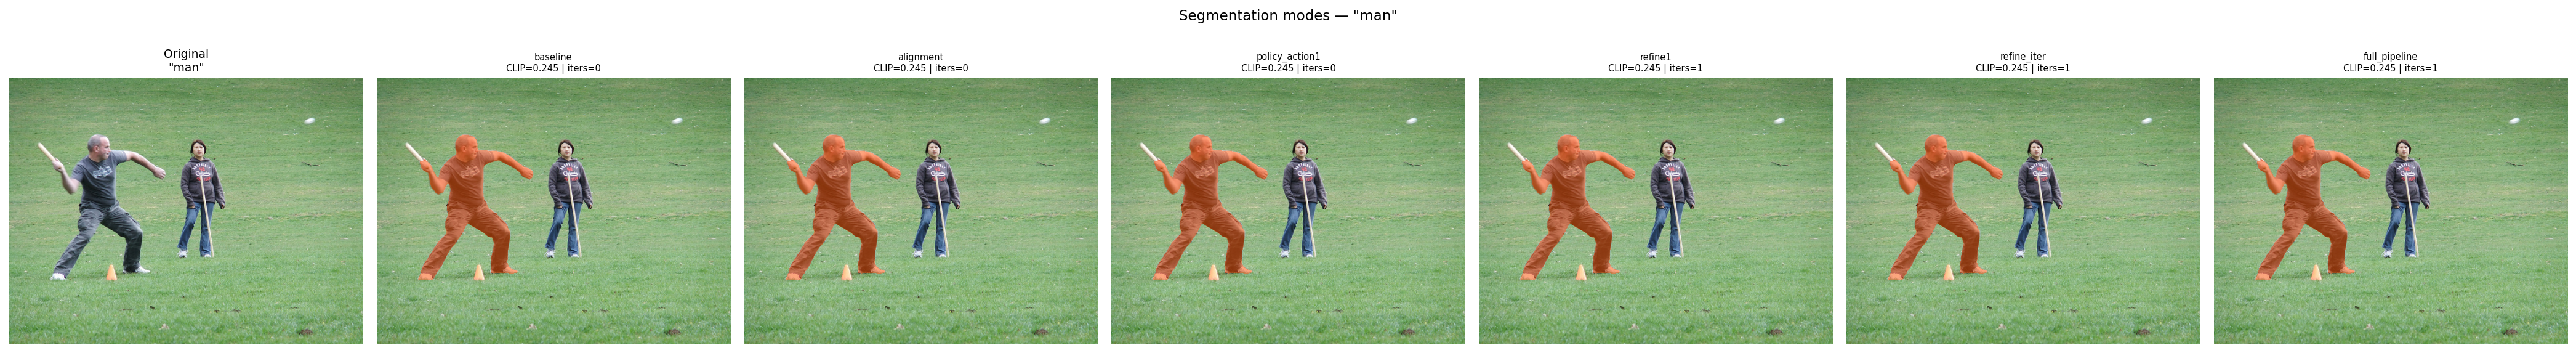

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ── Your image and prompt ─────────────────────────────────────────────────────
IMAGE_PATH = '/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017/test2017/000000000063.jpg'
PROMPT = 'man'  
# ── Load image ────────────────────────────────────────────────────────────────
image_rgb = np.array(Image.open(IMAGE_PATH).convert('RGB'))

sample = {
    'image_rgb': image_rgb,
    'prompt':    PROMPT,
    'sample_id': 'test',
    'image_id':  1,
}

# ── Run all modes ─────────────────────────────────────────────────────────────
# modes = ['baseline', 'alignment', 'oracle_action1', 'policy_action1', 'refine1', 'refine_iter', 'full_pipeline']

# oracle_action1 needs gt_mask — skip it if you don't have one
modes = ['baseline', 'alignment', 'policy_action1', 'refine1', 'refine_iter', 'full_pipeline']

results = {}
for mode in modes:
    print(f'Running {mode}...')
    results[mode] = pipeline.run(sample, mode=mode)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = len(modes) + 1  # +1 for original
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

# Original image
axes[0].imshow(image_rgb)
axes[0].set_title(f'Original\n"{PROMPT}"', fontsize=9)
axes[0].axis('off')

# Each mode
for i, mode in enumerate(modes):
    res  = results[mode]
    mask = ensure_uint8(res['selected_mask'])
    vis  = overlay_mask(image_rgb, mask, alpha=0.5, color=(255, 80, 0))

    clip  = res.get('clip_score', float('nan'))
    iters = res.get('n_refine_iters', 0)

    axes[i+1].imshow(vis)
    axes[i+1].set_title(f'{mode}\nCLIP={clip:.3f} | iters={iters}', fontsize=7)
    axes[i+1].axis('off')

plt.suptitle(f'Segmentation modes — "{PROMPT}"', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('all_modes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → all_modes.png')
from IPython.display import Image, display
imageName='all_modes.png'
display(Image(filename=imageName))

Running baseline...
Running alignment...
Running policy_action1...
Running refine1...
Running refine_iter...
Running full_pipeline...
Saved → all_modes.png


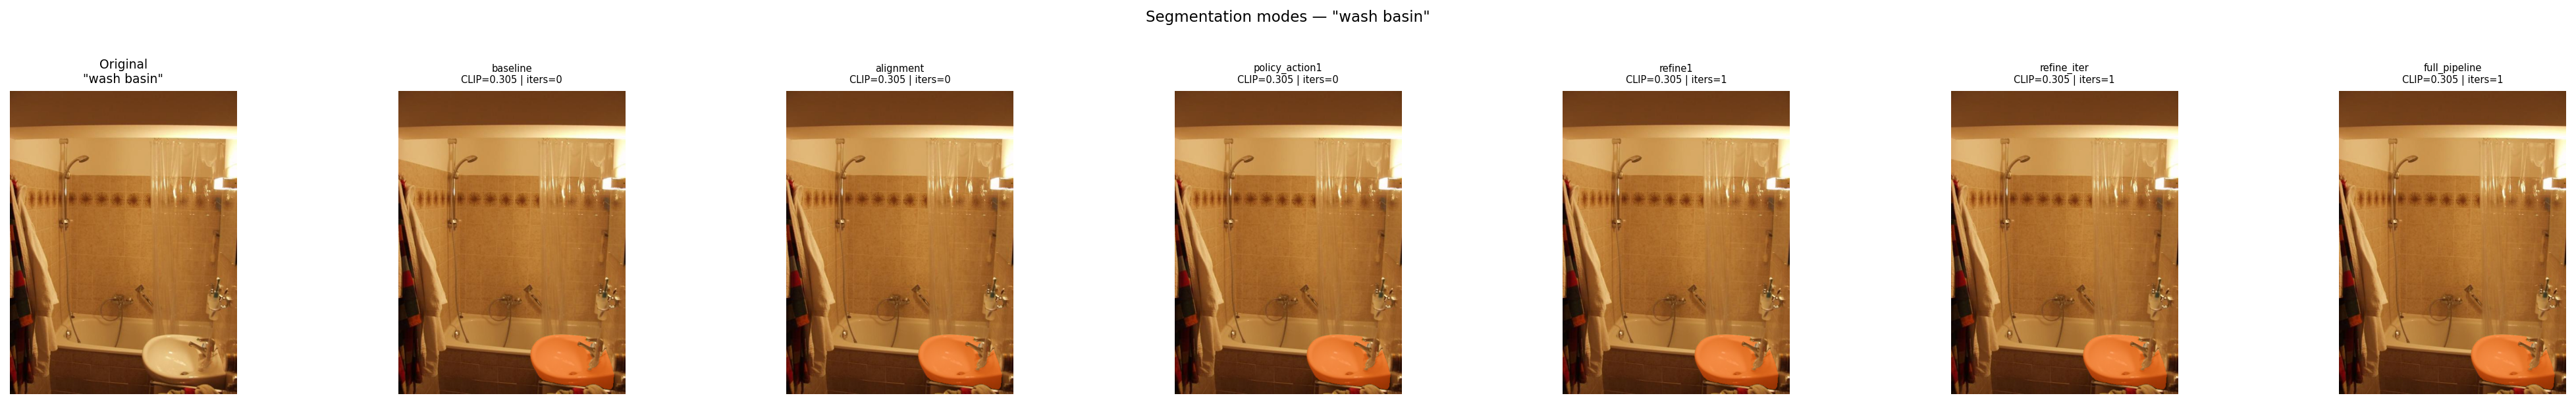

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# ── Your image and prompt ─────────────────────────────────────────────────────
IMAGE_PATH = '/kaggle/input/datasets/awsaf49/ade20k-dataset/ADEChallengeData2016/images/training/ADE_train_00000029.jpg'
PROMPT = 'wash basin'  
# ── Load image ────────────────────────────────────────────────────────────────
image_rgb = np.array(Image.open(IMAGE_PATH).convert('RGB'))

sample = {
    'image_rgb': image_rgb,
    'prompt':    PROMPT,
    'sample_id': 'test',
    'image_id':  1,
}

# ── Run all modes ─────────────────────────────────────────────────────────────
# modes = ['baseline', 'alignment', 'oracle_action1', 'policy_action1', 'refine1', 'refine_iter', 'full_pipeline']

# oracle_action1 needs gt_mask — skip it if you don't have one
modes = ['baseline', 'alignment', 'policy_action1', 'refine1', 'refine_iter', 'full_pipeline']

results = {}
for mode in modes:
    print(f'Running {mode}...')
    results[mode] = pipeline.run(sample, mode=mode)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_cols = len(modes) + 1  # +1 for original
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

# Original image
axes[0].imshow(image_rgb)
axes[0].set_title(f'Original\n"{PROMPT}"', fontsize=9)
axes[0].axis('off')

# Each mode
for i, mode in enumerate(modes):
    res  = results[mode]
    mask = ensure_uint8(res['selected_mask'])
    vis  = overlay_mask(image_rgb, mask, alpha=0.5, color=(255, 80, 0))

    clip  = res.get('clip_score', float('nan'))
    iters = res.get('n_refine_iters', 0)

    axes[i+1].imshow(vis)
    axes[i+1].set_title(f'{mode}\nCLIP={clip:.3f} | iters={iters}', fontsize=7)
    axes[i+1].axis('off')

plt.suptitle(f'Segmentation modes — "{PROMPT}"', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('all_modes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → all_modes.png')
from IPython.display import Image, display
imageName='all_modes.png'
display(Image(filename=imageName))